# Libraries used

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import textwrap
import numpy as np
from transformers import pipeline
import pandas as pd
import ollama
import json
import fitz
import os
import re
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from keybert import KeyBERT
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import math
import seaborn as sns

### GLOBAL VARIABLES AND GLOBAL STYLE (FIS-inspired green theme)

In [6]:
FIS_GREEN = "#0B6B3A"
FIS_LIGHT_GREEN = "#A8D5BA"
PDF_FOLDER = "downloaded_theses"

plt.rcParams.update({
    "figure.facecolor": "white" ,
    "axes.facecolor": "white",
    "axes.edgecolor": FIS_GREEN,
    "axes.labelcolor": FIS_GREEN,
    "xtick.color": FIS_GREEN,
    "ytick.color": FIS_GREEN,
    "text.color": FIS_GREEN,
    "axes.titlecolor": "black",
    "axes.grid": True,
    "grid.color": FIS_LIGHT_GREEN,
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.size": 11
})

sns.set_style("whitegrid")

### GLOBAL HELPER FUNCTIONS

In [43]:
def format_label(label, width=22):
    """Wrap long category names into shorter multi-line labels without splitting words."""
    return "\n".join(
        textwrap.wrap(
            str(label),
            width=width,
            break_long_words=False,
            break_on_hyphens=False
        )
    )

def sanitize_filename(name: str, max_length: int = 120) -> str:
    name = re.sub(r'[\\/*?:"<>|]', "_", name)
    name = re.sub(r"[\s_]+", "_", name).strip("_")
    return name[:max_length]

def clean_text(text):
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return None
    
    text = str(text)
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\b\d{1,3}\b', '', text)
    lines = [line for line in text.split('.') if len(line.strip()) > 40]
    return ' '.join(lines).strip()

def make_pdf_filename(row):
    year = str(row["submitted"])[-4:]
    author = str(row["author"]).strip()
    title = str(row["title_eng"]).strip()
    return sanitize_filename(f"{year}_-_{author}_-_{title}") + ".pdf"

def extract_text_from_pdf(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        text = ""
        for page in doc:
            text += page.get_text()
        doc.close()
        return text.strip()
    except Exception as e:
        print(f"Failed to extract {pdf_path}: {e}")
        return None

def load_thesis_text(row):
    filename = make_pdf_filename(row)
    full_path = os.path.join(PDF_FOLDER, filename)
    if os.path.exists(full_path):
        return extract_text_from_pdf(full_path)
    return None

### TEST OF OLLAMA CONNECTION

In [8]:
# test connection
try:
    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": "Say hello"}]
    )
    print("Ollama connected:", response["message"]["content"])
except ConnectionError as e:
    print("Ollama not running:", e)

Ollama connected: Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?


### DATA DOWNLOAD AND CLEANING

In [9]:
theses_metadata = pd.read_csv("theses_metadata.csv")
theses_metadata.head()

,listing_year,title,author,detail_url,title_eng,language,faculty,programme,department,submitted,defended,abstract,key_words,pdf_url
0,2020,Implementace knihovny pro použití Domain-Drive...,dužij maxim,https://vskp.vse.cz/79938_implementace-knihovn...,ddd infrastructure library on .net core platfo...,english,fakulta informatiky a statistiky,aplikovaná informatika/aplikovaná informatika,katedra informačních technologií,6. 5. 2020,25. 6. 2020,ddd (domain-driven design) is a popular approa...,ddd; domain-driven design; mongodb; .net core,https://insis.vse.cz/zp/71436
1,2020,Model-driven development a jeho využití při vý...,barchánková adéla,https://vskp.vse.cz/80049_model-driven-develop...,model driven development and its use in the de...,english,fakulta informatiky a statistiky,aplikovaná informatika/aplikovaná informatika,katedra informačních technologií,10. 5. 2020,24. 6. 2020,the main aim of this bachelor thesis is to pro...,model-driven development; modelling; software ...,https://insis.vse.cz/zp/71974
2,2020,Návrh uživatelského rozhraní pro chytré brýle,poláček robert,https://vskp.vse.cz/79987_navrh-uzivatelskeho-...,user interface concept for smart glasses,english,fakulta informatiky a statistiky,aplikovaná informatika/multimédia v ekonomické...,katedra multimédií,8. 5. 2020,23. 6. 2020,the goal of this thesis is to design a concept...,smart glasses; user interface; design,https://insis.vse.cz/zp/71250
3,2020,Serverless Computing: Benefits and challenges,drozdová zuzana,https://vskp.vse.cz/80120_serverless-computing...,serverless computing: benefits and challenges,english,fakulta informatiky a statistiky,aplikovaná informatika/aplikovaná informatika,katedra informačních technologií,11. 5. 2020,22. 6. 2020,"serverless computing is a relatively new, and ...",cloud computing; aws; serverless computing; fu...,https://insis.vse.cz/zp/72336
4,2020,Obchodní hodnota a vliv principů UX a UI v int...,nekhymchuk valeriya,https://vskp.vse.cz/80093_obchodni-hodnota-a-v...,the business value and influence of ux and ui ...,english,fakulta informatiky a statistiky,aplikovaná informatika/aplikovaná informatika,katedra informačních technologií,10. 5. 2020,22. 6. 2020,this bachelor thesis explores the importance o...,business value; ui; user interface; influence;...,https://insis.vse.cz/zp/68268


### Dual categories
Some theses are counted as part of dual programmes, we will take the first one and assume that the bachelor’s thesis mainly belongs to the first category listed. The same approach will be applied to the department.

In [10]:
theses_metadata['programme'] = (
    theses_metadata['programme']
    .astype(str)
    .str.split('/')
    .str[0]
    .str.strip()
)

theses_metadata['department'] = (
    theses_metadata['department']
    .astype(str)
    .str.split('/')
    .str[0]
    .str.strip()
)

In [11]:
theses_metadata.head()

,listing_year,title,author,detail_url,title_eng,language,faculty,programme,department,submitted,defended,abstract,key_words,pdf_url
0,2020,Implementace knihovny pro použití Domain-Drive...,dužij maxim,https://vskp.vse.cz/79938_implementace-knihovn...,ddd infrastructure library on .net core platfo...,english,fakulta informatiky a statistiky,aplikovaná informatika,katedra informačních technologií,6. 5. 2020,25. 6. 2020,ddd (domain-driven design) is a popular approa...,ddd; domain-driven design; mongodb; .net core,https://insis.vse.cz/zp/71436
1,2020,Model-driven development a jeho využití při vý...,barchánková adéla,https://vskp.vse.cz/80049_model-driven-develop...,model driven development and its use in the de...,english,fakulta informatiky a statistiky,aplikovaná informatika,katedra informačních technologií,10. 5. 2020,24. 6. 2020,the main aim of this bachelor thesis is to pro...,model-driven development; modelling; software ...,https://insis.vse.cz/zp/71974
2,2020,Návrh uživatelského rozhraní pro chytré brýle,poláček robert,https://vskp.vse.cz/79987_navrh-uzivatelskeho-...,user interface concept for smart glasses,english,fakulta informatiky a statistiky,aplikovaná informatika,katedra multimédií,8. 5. 2020,23. 6. 2020,the goal of this thesis is to design a concept...,smart glasses; user interface; design,https://insis.vse.cz/zp/71250
3,2020,Serverless Computing: Benefits and challenges,drozdová zuzana,https://vskp.vse.cz/80120_serverless-computing...,serverless computing: benefits and challenges,english,fakulta informatiky a statistiky,aplikovaná informatika,katedra informačních technologií,11. 5. 2020,22. 6. 2020,"serverless computing is a relatively new, and ...",cloud computing; aws; serverless computing; fu...,https://insis.vse.cz/zp/72336
4,2020,Obchodní hodnota a vliv principů UX a UI v int...,nekhymchuk valeriya,https://vskp.vse.cz/80093_obchodni-hodnota-a-v...,the business value and influence of ux and ui ...,english,fakulta informatiky a statistiky,aplikovaná informatika,katedra informačních technologií,10. 5. 2020,22. 6. 2020,this bachelor thesis explores the importance o...,business value; ui; user interface; influence;...,https://insis.vse.cz/zp/68268


# Introduction

# Analytical views

 First, we can just focus on analysing of our corpus with metadata we gathered. We can focus on questions like, what is the distribution of theses that are in english on Faculty of Informatics. How are they distributed and after that we can move to first analytical question

In [12]:
year_programme_table = pd.crosstab(
    theses_metadata['listing_year'],
    theses_metadata['programme']
)

year_programme_table["Total"] = year_programme_table.sum(axis=1)

year_programme_table

programme,aplikovaná informatika,data analytics,informační média a služby,kvantitativní metody v ekonomice,matematické metody v ekonomii,multimédia v ekonomické praxi,Total
listing_year,,,,,,,
2020,11,0,0,0,0,0,11
2021,9,0,0,0,0,0,9
2022,10,0,0,2,0,0,12
2023,12,0,0,4,4,0,20
2024,13,2,0,0,5,4,24
2025,12,14,2,0,10,3,41
2026,13,20,2,0,4,6,45


<Figure size 1400x700 with 0 Axes>

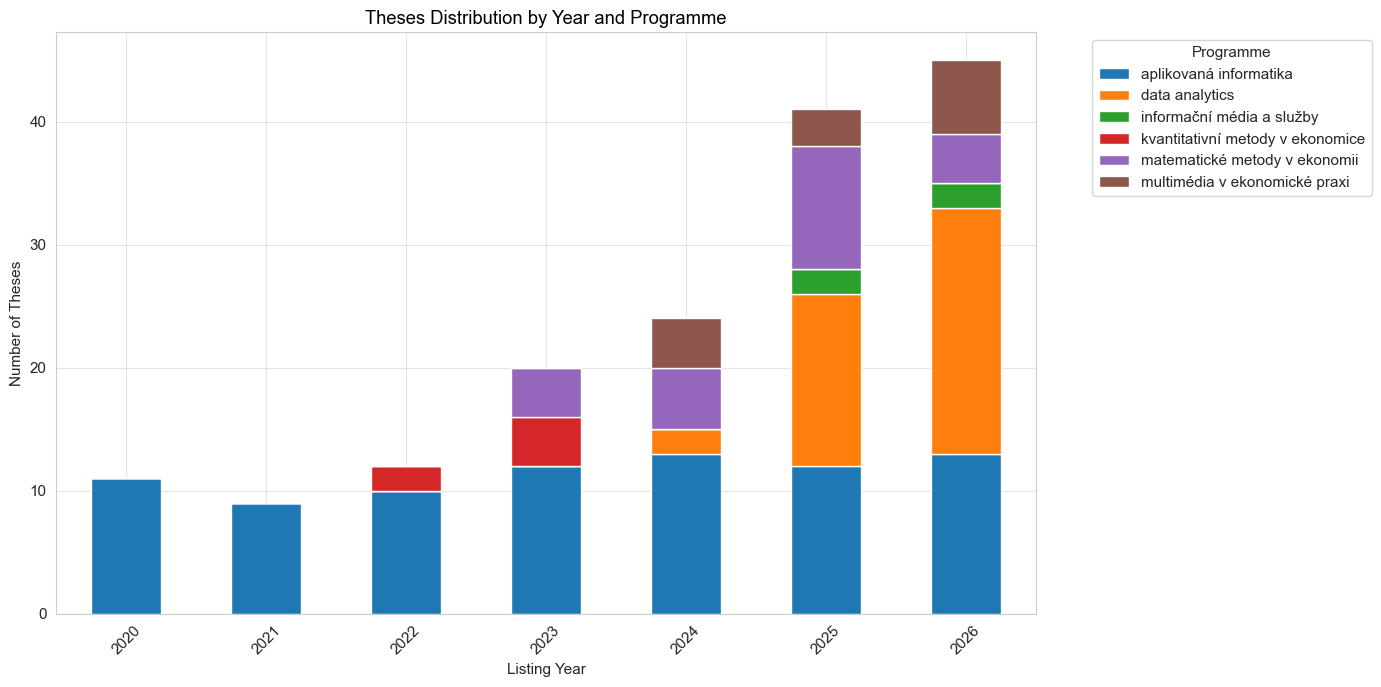

In [13]:
# -----------------------------
# 1. Listing Year Distribution by Programe - Plot stacked bar chart
# -----------------------------
plt.figure(figsize=(14, 7))

year_programme_table.iloc[:, :-1].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    color=[
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b"   # brown
]
)

plt.title('Theses Distribution by Year and Programme')
plt.xlabel('Listing Year')
plt.ylabel('Number of Theses')
plt.xticks(rotation=45)
plt.legend(
    title='Programme',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

Based on this graph, we can see a rapid increase in the number of theses submitted in English. This trend suggests a growing preference for English as the main academic language, which can be explained by new academic programs that focus more on English teaching (as can be seen in the increase of Data Analytics theses submitted from 2024) or by an interest in reaching a wider audience (as shown by the steady submission of Applied Informatics theses).

# 1. Question – Is there an increase in AI-focused bachelor theses from 2020 to present?
In this part of the analysis, we will focus on identifying theses whose main topic is related to the field of artificial intelligence. At this stage, we will not load or analyse the full text of the theses, instead we will work only with the available metadata.

## Methodology

To classify whether a thesis is AI-focused, we employ an ensemble approach combining two 
complementary text classification methods applied to the thesis abstracts.

**Zero-Shot Classification** uses the `cross-encoder/nli-deberta-v3-small` model from 
HuggingFace Transformers. This approach requires no training data — the model evaluates each 
abstract against two label sets: one representing AI-related fields (artificial intelligence, 
machine learning, deep learning, neural networks, data science) and one representing unrelated 
fields (humanities, social science, economics, law, medicine). A confidence threshold is applied 
to reduce false positives.

**LLM Classification** uses a locally running Ollama instance to prompt an LLM to classify each 
abstract as either AI-focused or not, returning a structured JSON response with a label and 
confidence score. Running the model locally ensures that thesis data does not leave the machine.

The final classification combines both approaches, a thesis is marked as AI-focused if either 
classifier returns a positive result. This ensemble strategy reduces false negatives, meaning a 
thesis is only excluded if both classifiers independently agree it is not AI-related.

First we check if we can put the whole abstract into our classifier, and what should be the ideal lenght. We want the lowest possible, so we safe on time and token resources but also we want as much information as possible without it being truncated

In [14]:
print(theses_metadata["abstract"].isna().sum(), "missing abstracts")
print(theses_metadata["abstract"].str.strip().eq("").sum(), "empty abstracts")

# check length distribution
theses_metadata["abstract_length"] = theses_metadata["abstract"].str.len()
print(theses_metadata["abstract_length"].describe())

truncated = theses_metadata[theses_metadata["abstract_length"] > 2048]
print(f"{len(truncated)} abstracts exceed 2048 characters and will be truncated")


0 missing abstracts
0 empty abstracts
count     162.000000
mean     1275.728395
std       435.382248
min       296.000000
25%       994.000000
50%      1228.500000
75%      1512.750000
max      2767.000000
Name: abstract_length, dtype: float64
10 abstracts exceed 2048 characters and will be truncated


75 % of all abstract have 1512 characters or less, so we will chose something close to it in base of 2^N 

### Zero-Shot classification

In [15]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

candidate_labels = [
    "artificial intelligence, machine learning, deep learning, neural networks, data science, text analytics, classification task, ChatBots, ChatGPT, LLM, Large language models, ",
    "humanities, social science, economics, law, medicine, unrelated to technology, photography, design, ecology"
]

def classify_thesis(abstract):
    if pd.isna(abstract) or abstract.strip() == "":
        return None, None
    
    result = classifier(
        abstract[:2048], 
        candidate_labels,
        hypothesis_template="This thesis is about {}."
    )
    
    top_label = result["labels"][0]
    top_score = result["scores"][0]
    
    # match the exact first label string
    is_ai = top_label == candidate_labels[0] and top_score >= 0.85
    return is_ai, top_score

theses_metadata[["is_ai_focused_zero_shot", "ai_confidence_zero_shot"]] = theses_metadata["abstract"].apply(
    lambda x: pd.Series(classify_thesis(x))
)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 5304.75it/s]


### LLM classification

In [16]:
def classify_thesis(abstract):
    if pd.isna(abstract) or abstract.strip() == "":
        return None, None
    
    prompt = f"""You are a research classifier. Classify whether the following thesis abstract is related to artificial intelligence, machine learning, text analytics or not any of those fields.

Abstract: {abstract[:2024]}

Respond ONLY with valid JSON in this exact format, nothing else:
{{"label": "related to AI", "confidence": 0.95}}

Where label is either "related to AI" or "unrelated to AI", and confidence is a float between 0 and 1. Assign to related to AI if your condifance is at least 0.85, if not assign it to unrelated to AI category"""

    response = ollama.chat(
        model="llama3.2",  # or whatever model you have pulled
        messages=[{"role": "user", "content": prompt}]
    )
    
    try:
        result = json.loads(response["message"]["content"])
        is_ai = result["label"] == "related to AI"
        confidence = result["confidence"]
        return is_ai, confidence
    except json.JSONDecodeError:
        return False, -1

theses_metadata[["is_ai_focused_llm", "ai_confidence_llm"]] = theses_metadata["abstract"].apply(
    lambda x: pd.Series(classify_thesis(x))
)

In [17]:
theses_metadata["is_ai_focused"] = (
    theses_metadata["is_ai_focused_llm"] | theses_metadata["is_ai_focused_zero_shot"]
)

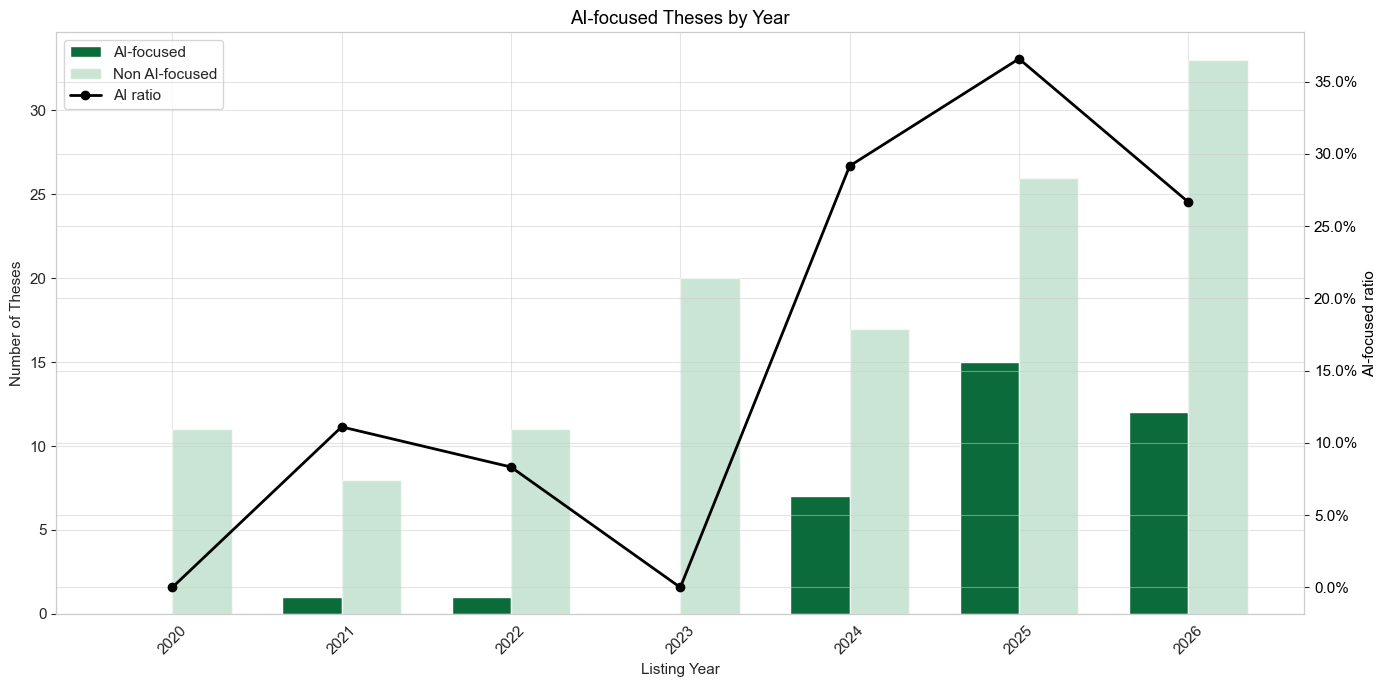

In [18]:
# -----------------------------
# Add is_ai_focused to year_programme_table
# -----------------------------
ai_by_year = theses_metadata.groupby("listing_year")["is_ai_focused"].agg(
    ai_count="sum",
    total_count="count"
)
ai_by_year["non_ai_count"] = ai_by_year["total_count"] - ai_by_year["ai_count"]
ai_by_year["ai_ratio"] = ai_by_year["ai_count"] / ai_by_year["total_count"]

# -----------------------------
# Plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(14, 7))

x = range(len(ai_by_year.index))
width = 0.35

bars_ai = ax1.bar(
    [i - width/2 for i in x],
    ai_by_year["ai_count"],
    width=width,
    label="AI-focused",
    color= FIS_GREEN
)
bars_non_ai = ax1.bar(
    [i + width/2 for i in x],
    ai_by_year["non_ai_count"],
    width=width,
    label="Non AI-focused",
    color=FIS_LIGHT_GREEN,
    alpha=0.6
)

# line overlay for AI ratio trend
ax2 = ax1.twinx()
ax2.plot(
    list(x),
    ai_by_year["ai_ratio"],
    color="black",
    marker="o",
    linewidth=2,
    label="AI ratio"
)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.set_ylabel("AI-focused ratio", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# labels and formatting
ax1.set_xticks(list(x))
ax1.set_xticklabels(ai_by_year.index, rotation=45)
ax1.set_xlabel("Listing Year")
ax1.set_ylabel("Number of Theses")
ax1.set_title("AI-focused Theses by Year")

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

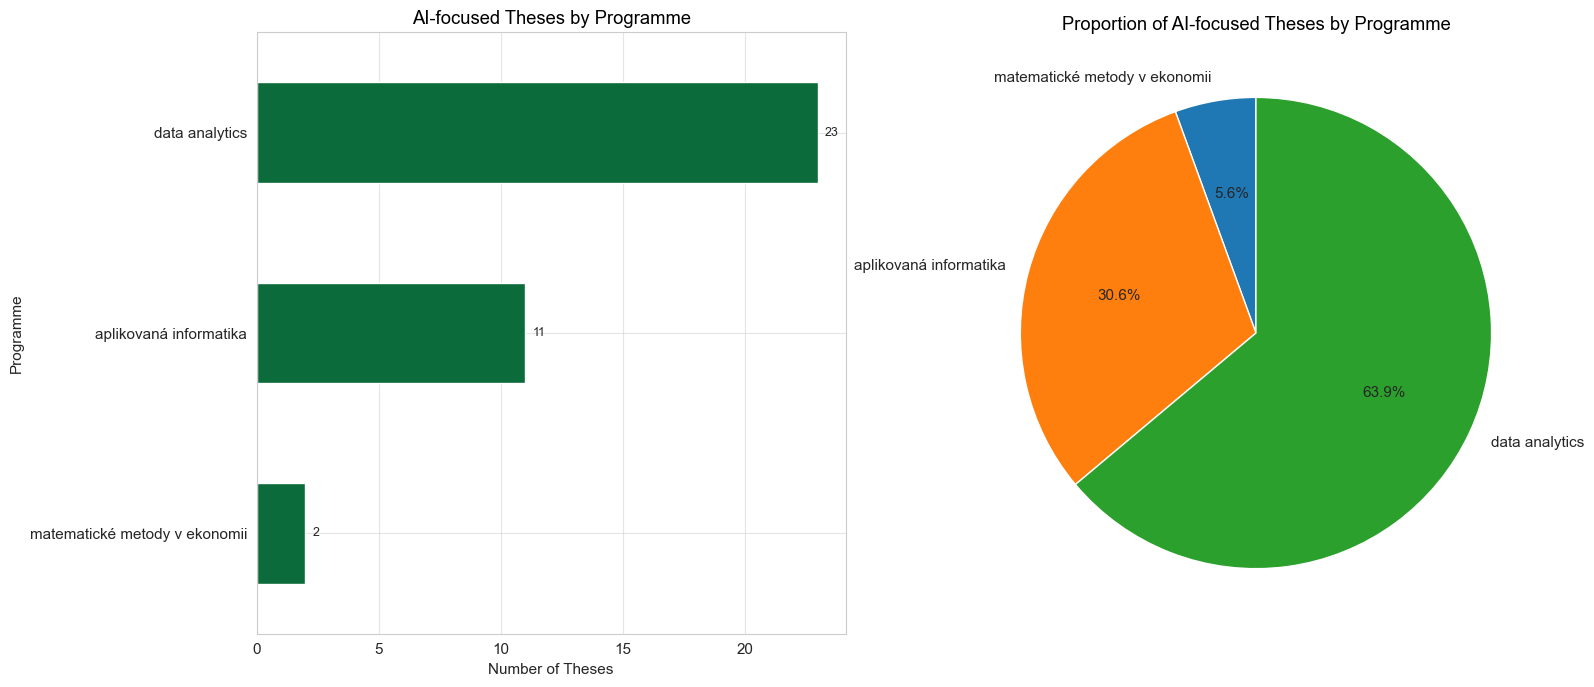

In [19]:
# -----------------------------
# AI-focused Theses by Programme
# -----------------------------
ai_by_programme = theses_metadata[theses_metadata["is_ai_focused"] == True].groupby("programme").size().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Horizontal bar chart ---
ai_by_programme.plot(
    kind="barh",
    ax=axes[0],
    color=FIS_GREEN,
    edgecolor="white"
)
axes[0].set_title("AI-focused Theses by Programme")
axes[0].set_xlabel("Number of Theses")
axes[0].set_ylabel("Programme")

# add value labels on bars
for i, v in enumerate(ai_by_programme):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

# --- Right: Pie chart showing proportion ---
ai_by_programme.plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%",
    colors=[
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd",
        "#8c564b",
        "#e377c2",
        "#7f7f7f"
    ],
    startangle=90,
    ylabel=""
)
axes[1].set_title("Proportion of AI-focused Theses by Programme")

plt.tight_layout()
plt.show()

In [20]:
theses_metadata.to_csv("theses_metadata_classified.csv", index= False)

# 1. Question – Is there an increase in AI-focused bachelor theses from 2020 to present?

## Conclusion

The data confirms a significant increase in AI-focused bachelor theses from 2020 to the 
present, however the results must be interpreted with context.

Between 2020 and 2023, AI-focused theses were nearly absent, with only 1 thesis classified as 
AI-related in both 2021 and 2022, and none in 2020 and 2023. A sharp turning point occurs in 
2024, where the AI ratio jumps to approximately 29%, rising further to 36% in 2025 before 
settling at around 27% in 2026.

However, this increase cannot be attributed solely to growing interest in AI. The analysis 
covers only English-language theses, which introduces a significant bias. The **Data 
Analytics** programme, which accounts for 63.9% of all AI-focused theses, is a partially 
English-taught programme whose first students only became eligible to submit bachelor theses 
around 2024, as the programme launched in 2020 and typically requires four years to complete. 
The sharp rise in AI-focused theses from 2024 onwards therefore likely reflects the arrival of 
this first Data Analytics cohort as much as it reflects a genuine broader trend toward AI 
research. Theses written in Czech were omitted during the data gathering phase and are not 
represented in this analysis.

From a programme perspective, the concentration of AI-focused theses in Data Analytics (63.9%) 
and Aplikovaná Informatika (30.6%) further supports this interpretation. The minimal 
representation from Matematické Metody v Ekonomii (5.6%) and the complete absence of other 
programmes is likely a reflection of the language selection rather than a lack of AI research 
interest elsewhere.

In summary, while the data shows a **clear and sustained increase** in AI-focused bachelor 
theses from 2024 onwards, the result is significantly shaped by the maturation of the Data 
Analytics programme and the restriction of data gathering to English-language theses. A more 
complete analysis would require extending the classification to Czech-language theses to allow 
fair comparison across all programmes and years.

# 2. Question – What areas are the AI tools used in?

## Methodology

To answer this question, we move beyond the metadata used in the previous analysis and work 
directly with the full text of the theses. PDF files stored in a local folder are matched to 
their corresponding metadata records using a filename convention based on the submission year, 
author name, and English title. Text is extracted from each PDF using the PyMuPDF library and 
cleaned to remove noise introduced by the PDF format such as excessive whitespace and page 
numbers.

For keyword extraction, we apply **KeyBERT**, a keyword extraction method that uses sentence 
embeddings to identify the most representative phrases in each document. Rather than treating 
the corpus as a whole, KeyBERT is applied to each thesis individually, extracting up to 10 
keyphrases per document using Maximal Marginal Relevance (MMR) to ensure diversity among the 
extracted terms. Both single words and phrases of up to three words are considered, allowing 
the model to capture meaningful expressions such as "machine learning" or "convolutional neural 
network".

The extracted keywords, combined with the thesis abstract, are then passed to a locally running 
**Ollama LLM** for industry classification. The model is prompted to assign each thesis to one 
of a predefined set of industry categories such as healthcare and medicine, finance and banking, 
business and management, and others. Providing a fixed category list ensures consistent and 
comparable results across all theses.

The analysis is performed on the AI-focused subset identified in Question 1, allowing us to 
examine not just whether AI is being researched, but in which real-world domains it is being 
applied.

### Loading classified metadata first

In [23]:
theses_metadata = pd.read_csv("theses_metadata_classified.csv")

In [41]:
theses_metadata["full_text"] = theses_metadata.apply(load_thesis_text, axis=1)

matched = theses_metadata["full_text"].notna().sum()
total = len(theses_metadata)
print(f"Successfully loaded: {matched}/{total} theses")
print(f"Failed to load: {total - matched}/{total} theses")

print(f"\nAI-focused theses:     {len(theses_metadata[theses_metadata["is_ai_focused"] == True])} ({theses_metadata[theses_metadata["is_ai_focused"] == True]['full_text'].notna().sum()} PDFs loaded)")
print(f"Non AI-focused theses: {len(theses_metadata[theses_metadata["is_ai_focused"] == False])} ({theses_metadata[theses_metadata["is_ai_focused"] == False]['full_text'].notna().sum()} PDFs loaded)")

Successfully loaded: 120/162 theses
Failed to load: 42/162 theses

AI-focused theses:     36 (26 PDFs loaded)
Non AI-focused theses: 126 (94 PDFs loaded)


In [44]:
theses_metadata["full_text_clean"] = theses_metadata["full_text"].apply(clean_text)

In [76]:
docs = theses_metadata["full_text_clean"].dropna().tolist()

kw_model = KeyBERT()

def extract_keywords_from_text(text, top_n=10):
    if text is None or (isinstance(text, float) and np.isnan(text)) or str(text).strip() == "":
        return None, None
    
    keywords = kw_model.extract_keywords(
        str(text),
        keyphrase_ngram_range=(1, 3),
        stop_words="english",
        top_n=top_n,
        use_mmr=True,
        diversity=0.7
    )
    
    if not keywords:
        return None, None
    
    main_topic = keywords[0][0]           # highest scoring keyword
    doc_topics = [kw for kw, score in keywords]  # all keywords
    
    return main_topic, doc_topics


theses_metadata[["main_topic", "doc_topics"]] = theses_metadata["full_text_clean"].apply(
    lambda x: pd.Series(extract_keywords_from_text(x))
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11228.12it/s]


In [77]:
theses_metadata["doc_topics"]

0                           [ddd mongodb introduction, choose core domain, university economics prague, project use layered, gratitude directly indirectly, zimarev 2019 usage, different integration, related tables locked, surname surname email, ieventhandler getrequiredservice handlergenerictype]
1                                                        [modelování informační technologie, mdd druhá, metasystem overloaded methods, languages fortran cobol, transition behaviour definition, finished weeks requirements, error appears newly, serve server, license note price, apply defined batch]
2                                                          [smart glasses concept, poláček user interface, economics prague faculty, table contents introduction, developers probability model, capabilities change os, products slow, element touch response, 732073 worldwide, alexa rundowns calendar]
3                                                       [thesis entitled serverless, prague, business appl

In [78]:
theses_metadata["main_topic"]

0                ddd mongodb introduction
1       modelování informační technologie
2                   smart glasses concept
3              thesis entitled serverless
4             university economics prague
5                   analysis usage google
6                  aplikovaná informatika
7                svícení rozdilných filmů
8                   zahrnuje google cloud
9                    film produkční firma
10                chatbot design recrubot
11           study aplikovaná informatika
12                     prague help reader
13             medium enterprises czechia
14            film propaganda vypracovala
15            augmented reality marketing
16           blockchain czech statistical
17                 škola ekonomická praze
18                 datasetu jako nejlepší
19         program aplikovaná informatika
20                  crop yield prediction
21                       investment czech
22               volatility egarch models
23                   thesis design

In [79]:
INDUSTRY_CATEGORIES = [
    "healthcare and medicine",
    "finance and banking",
    "business and management",
    "retail and e-commerce",
    "education and research",
    "cybersecurity",
    "software development",
    "data science and analytics",
    "marketing and media",
    "logistics and supply chain",
    "energy and environment",
    "manufacturing and industry",
    "public sector and government",
    "other"
]

In [80]:
def classify_industry(main_topic, doc_topics, abstract):
    # handle missing values
    if (main_topic is None or (isinstance(main_topic, float) and np.isnan(main_topic))):
        return None, None
    
    # format doc_topics nicely
    if doc_topics is None or (isinstance(doc_topics, float) and np.isnan(doc_topics)):
        topics_str = main_topic
    else:
        topics_str = ", ".join(doc_topics) if isinstance(doc_topics, list) else str(doc_topics)

    abstract_str = "" if (abstract is None or (isinstance(abstract, float) and np.isnan(abstract))) else str(abstract)
    
    prompt = f"""You are a research classifier. Based on the following keywords extracted from a bachelor thesis, assign it to the most relevant industry category.

Main topic: {main_topic}
Additional keywords: {topics_str}
Abstract: {abstract_str}

Available categories:
{chr(10).join(f"- {cat}" for cat in INDUSTRY_CATEGORIES)}

Respond ONLY with valid JSON in this exact format, nothing else:
{{"category": "exact category name from the list", "confidence": 0.95, "reasoning": "one sentence explanation"}}"""

    try:
        response = ollama.chat(
            model="llama3.2",
            messages=[{"role": "user", "content": prompt}]
        )
        
        result = json.loads(response["message"]["content"])
        
        # validate category is in our list
        if result["category"] not in INDUSTRY_CATEGORIES:
            result["category"] = "other"
            
        return result["category"], result["confidence"]
    
    except (json.JSONDecodeError, KeyError):
        return None, None



theses_metadata[["industry_category", "industry_confidence"]] = theses_metadata.apply(
    lambda row: pd.Series(classify_industry(
        row["main_topic"], 
        row["doc_topics"],
        row["abstract"]
    )),
    axis=1
)


# quick summary
print(theses_metadata["industry_category"].value_counts())

industry_category
data science and analytics      29
software development            23
marketing and media             18
business and management         13
education and research          13
finance and banking             10
public sector and government     5
energy and environment           5
retail and e-commerce            2
cybersecurity                    1
logistics and supply chain       1
Name: count, dtype: int64


In [81]:
theses_metadata.to_csv("theses_metadata_classified_industry.csv", index = False)

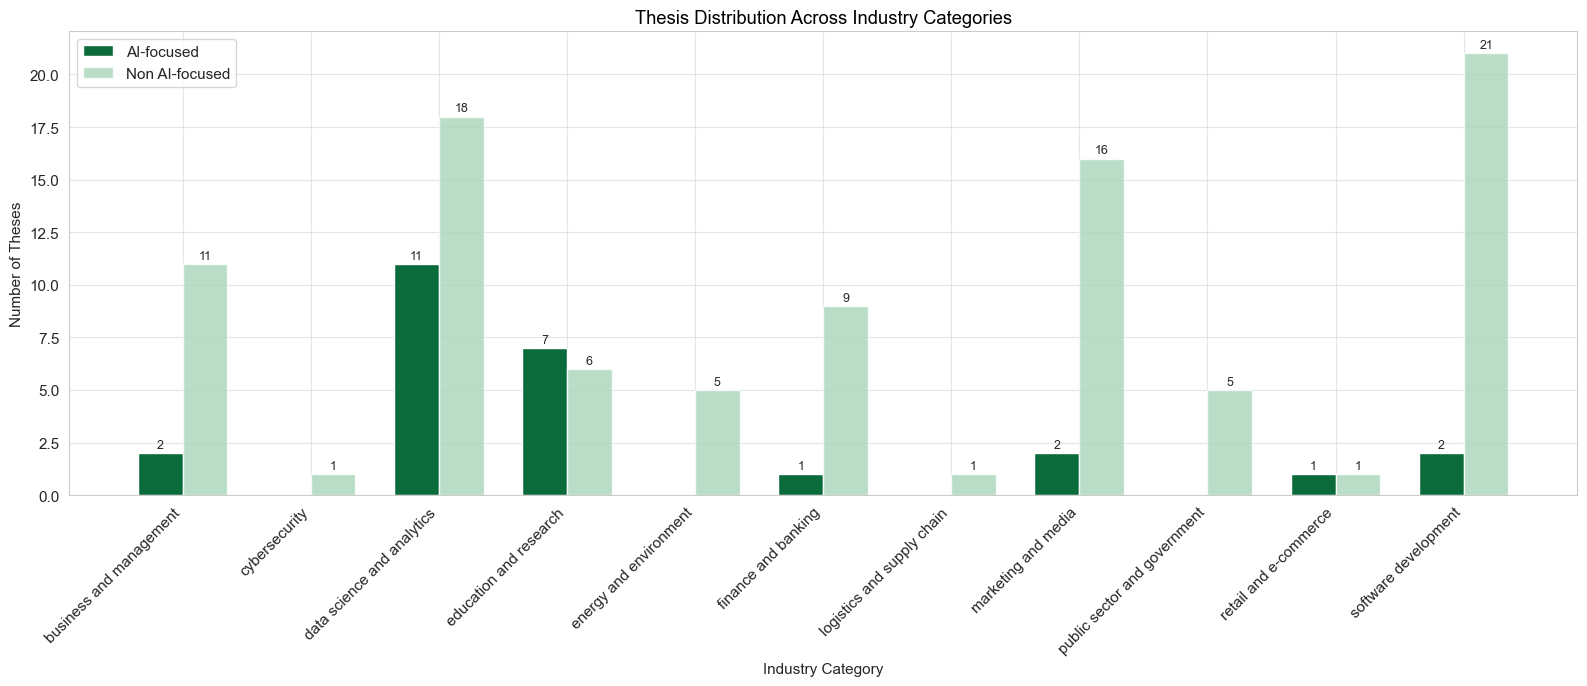

In [82]:
# count by industry category
ai_counts = theses_metadata[theses_metadata["is_ai_focused"] == True]["industry_category"].value_counts()
non_ai_counts = theses_metadata[theses_metadata["is_ai_focused"] == False]["industry_category"].value_counts()

# align both series to same categories
all_categories = sorted(set(ai_counts.index) | set(non_ai_counts.index))
ai_vals = [ai_counts.get(cat, 0) for cat in all_categories]
non_ai_vals = [non_ai_counts.get(cat, 0) for cat in all_categories]

x = np.arange(len(all_categories))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))

bars_ai = ax.bar(x - width/2, ai_vals, width, label="AI-focused", color=FIS_GREEN, edgecolor="white")
bars_non_ai = ax.bar(x + width/2, non_ai_vals, width, label="Non AI-focused", color=FIS_LIGHT_GREEN, alpha=0.8, edgecolor="white")

# value labels on bars
for bar in bars_ai:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

for bar in bars_non_ai:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(all_categories, rotation=45, ha="right")
ax.set_xlabel("Industry Category")
ax.set_ylabel("Number of Theses")
ax.set_title("Thesis Distribution Across Industry Categories")
ax.legend()

plt.tight_layout()
plt.show()

# 2. Question – What areas are the AI tools used in?
## Conclusion

The analysis reveals that AI tools are being applied across a diverse range of industry areas, 
with a clear concentration in a few dominant domains.

**Data science and analytics** emerges as the most common area for AI-focused theses with 11 
out of 36, which is unsurprising given the student population, Data Analytics and Aplikovaná 
Informatika students naturally gravitate toward data-driven applications of AI. Notably, this 
category also has the highest non-AI count (18), confirming it as the core research domain of 
the programmes regardless of AI involvement.

**Education and research** is the second most frequent area for AI-focused theses with 7, 
suggesting that students are actively exploring AI as a subject of academic inquiry itself — 
studying its methods, evaluating its performance, or applying it to educational tools and 
platforms.

**Business and management** (2) and **marketing and media** (2) appear among AI-focused theses 
but remain modest, suggesting these are emerging areas where students are beginning to apply AI 
rather than established research directions.

Interestingly, **software development** is the most common research area overall with 21 theses, 
yet only 2 of these are AI-focused. This does not mean AI is absent from software development 
theses, rather, their primary focus lies elsewhere, such as architecture, testing, or 
development methodology, with AI playing a supporting rather than central role.

Areas such as **energy and environment**, **logistics and supply chain**, and **finance and 
banking** show limited AI-focused representation despite being active areas of AI adoption 
in industry, suggesting these remain underexplored as primary research topics among students.

In summary, AI is most prominently the central focus in data science, analytics, and 
education-related theses, reflecting the technical orientation of the programmes. The spread 
of AI as a primary research topic across other industries remains narrow, these areas could be
broaden with new courses on specific uses of AI by the school.

# 3. Question – What AI techniquest are most commonly used?

## Methodology

To identify the AI techniques used in each thesis, we build directly on the keyword extraction 
and classification pipeline established in Question 2. **KeyBERT** was already applied to each 
thesis to extract up to 10 representative keyphrases, capturing specific methods, tools, and 
frameworks mentioned throughout the text.

These extracted keywords, together with the thesis abstract, are passed to a locally running 
**Ollama LLM** which is prompted to identify any specific technologies, tools, frameworks, 
programming languages, or methods used or studied in the thesis. The model returns a structured 
list of technologies alongside a dominant technology category selected from a predefined list 
covering areas such as deep learning and neural networks, natural language processing, large 
language models and generative AI, decision trees and ensemble methods, and others.

The technologies used doesn't have any predefined categories and is purely discoverd by the LLM itself.
There is also not any specific length or number of technologies that are assigned to each work.

In [86]:
TECH_CATEGORIES = [
    # AI and Machine Learning methods
    "deep learning and neural networks",
    "natural language processing",
    "computer vision",
    "decision trees and ensemble methods",
    "regression and statistical learning",
    "clustering and unsupervised learning",
    "reinforcement learning",
    "large language models and generative AI",
    "recommendation systems",
    
    # Data and Analytics
    "data analysis and statistics",
    "business intelligence and reporting",
    "database and data engineering",
    "big data and data pipelines",
    
    # Software and Engineering
    "web development",
    "mobile development",
    "cloud and devops",
    "software engineering and architecture",
    "cybersecurity",
    
    "other"
]

In [89]:
def extract_technologies(main_topic, doc_topics, abstract):
    if (main_topic is None or (isinstance(main_topic, float) and np.isnan(main_topic))):
        return None

    topics_str = ", ".join(doc_topics) if isinstance(doc_topics, list) else str(doc_topics or "")
    abstract_str = "" if (abstract is None or (isinstance(abstract, float) and np.isnan(abstract))) else str(abstract)

    prompt = f"""You are a research analyst. Based on the following information from a bachelor thesis, extract any specific technologies, tools, frameworks, programming languages, or methods that were used or studied.

Main topic: {main_topic}
Keywords: {topics_str}
Abstract: {abstract_str}

Examples of what to extract: Python, TensorFlow, React, BERT, ChatGPT, LLM, SQL, machine learning, regression analysis, A/B testing, REST API, Docker, etc.

Available technology categories (pick the single most relevant one):
{chr(10).join(f"- {cat}" for cat in TECH_CATEGORIES)}

Respond ONLY with valid JSON in this exact format, nothing else:
{{
    "technologies": ["tech1", "tech2", "tech3"],
    "category": "exact category name from the list above",
    "confidence": 0.95
}}

If no specific technologies are mentioned, return an empty list for technologies."""

    try:
        response = ollama.chat(
            model="llama3.2",
            messages=[{"role": "user", "content": prompt}]
        )
        
        result = json.loads(response["message"]["content"])
        
        # validate category is in our list
        if result.get("category") not in TECH_CATEGORIES:
            result["category"] = "other"
            
        return result
    
    except (json.JSONDecodeError, KeyError):
        return None

# run on all theses
results = theses_metadata.apply(
    lambda row: extract_technologies(
        row["main_topic"],
        row["doc_topics"],
        row["abstract"]
    ),
    axis=1
)


In [90]:
theses_metadata["technologies"] = results.apply(
    lambda x: x["technologies"] if x and "technologies" in x else []
)
theses_metadata["tech_category"] = results.apply(
    lambda x: x["category"] if x and "category" in x else None
)

In [91]:
print(theses_metadata["tech_category"].value_counts())

tech_category
data analysis and statistics               58
database and data engineering               8
other                                       7
large language models and generative AI     6
deep learning and neural networks           6
cloud and devops                            5
natural language processing                 5
web development                             5
business intelligence and reporting         2
decision trees and ensemble methods         2
computer vision                             1
reinforcement learning                      1
Name: count, dtype: int64


In [92]:
print(theses_metadata[theses_metadata["is_ai_focused"] == True]["tech_category"].value_counts())

tech_category
large language models and generative AI    6
data analysis and statistics               5
deep learning and neural networks          5
natural language processing                3
decision trees and ensemble methods        2
cloud and devops                           1
other                                      1
database and data engineering              1
reinforcement learning                     1
Name: count, dtype: int64


In [93]:
print(theses_metadata[theses_metadata["is_ai_focused"] == True]["technologies"])

18                                                                                                                                       [Python]
28                                                                                 [Amazon Connect Wisdom, Kendra, Microsoft Teams, Web browsers]
53                                      [deep learning and neural networks, large language models and generative AI, natural language processing]
55                                                                                                               [Python, XGBoost, Random Forest]
66                                                             [ChatGPT, Generative Pre-trained Transformers (GPTs), Large Language Models (LLM)]
67                                                                                                                        [Python, LSTM, XGBoost]
68                                                                                                                 [transfor

### WordCloud AI technologies

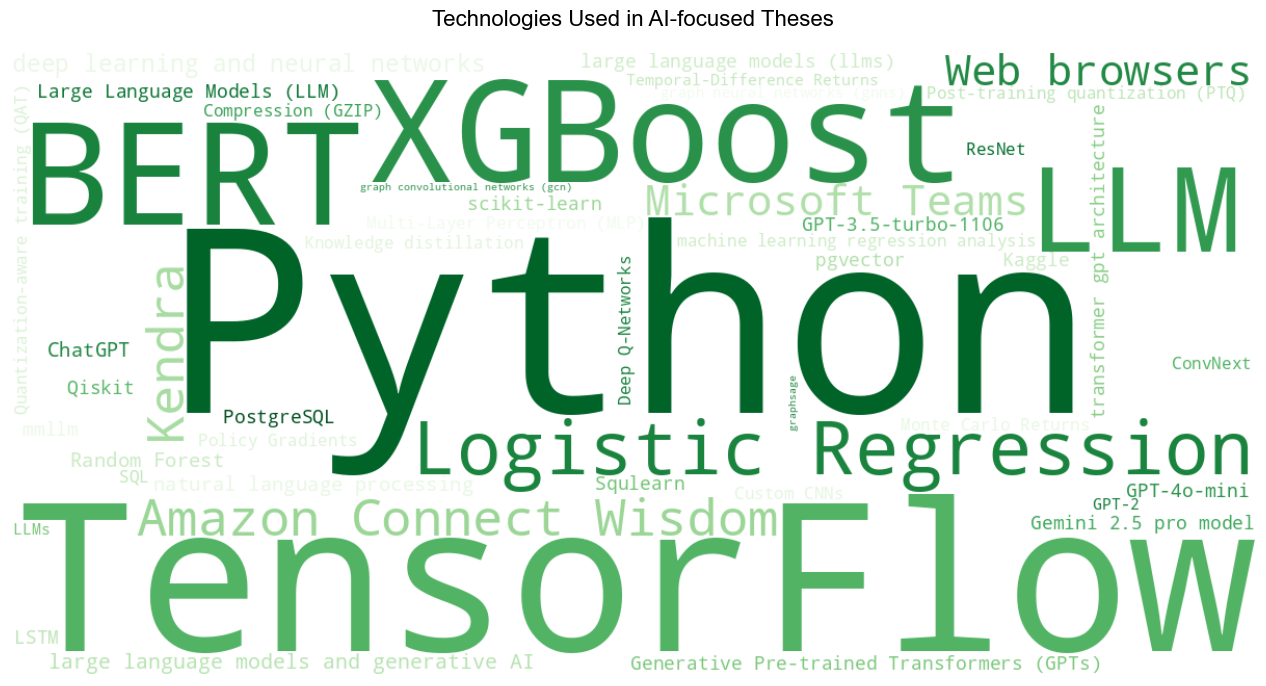

In [96]:
# flatten all technology lists from AI-focused theses
ai_technologies = [
    tech
    for techs in theses_metadata[theses_metadata["is_ai_focused"] == True]["technologies"].dropna()
    if isinstance(techs, list)
    for tech in techs
]

# count frequencies for wordcloud weighting
tech_counts = Counter(ai_technologies)

# generate wordcloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens",
    max_words=50,
    collocations=False
).generate_from_frequencies(tech_counts)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Technologies Used in AI-focused Theses", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### WordCloud not AI

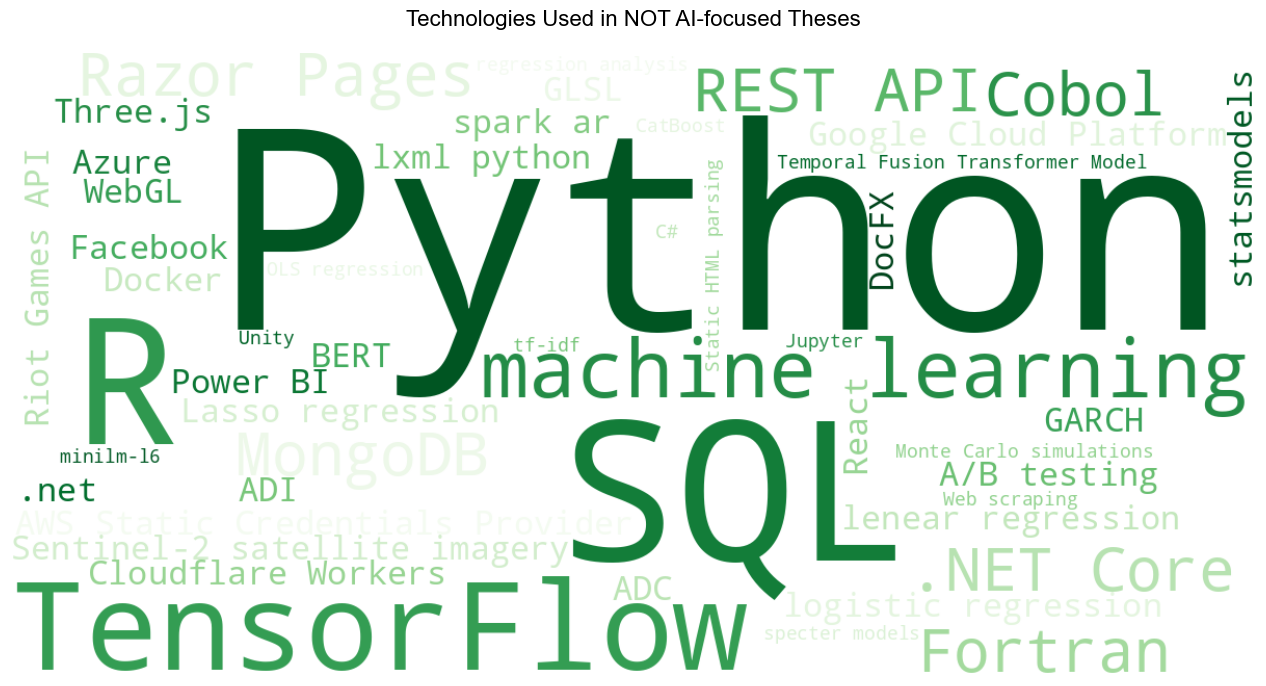

In [110]:
not_ai_technologies = [
    tech
    for techs in theses_metadata[theses_metadata["is_ai_focused"] == False]["technologies"].dropna()
    if isinstance(techs, list)
    for tech in techs
]

# count frequencies for wordcloud weighting
tech_counts = Counter(not_ai_technologies )

# generate wordcloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens",
    max_words=50,
    collocations=False
).generate_from_frequencies(tech_counts)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Technologies Used in NOT AI-focused Theses", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

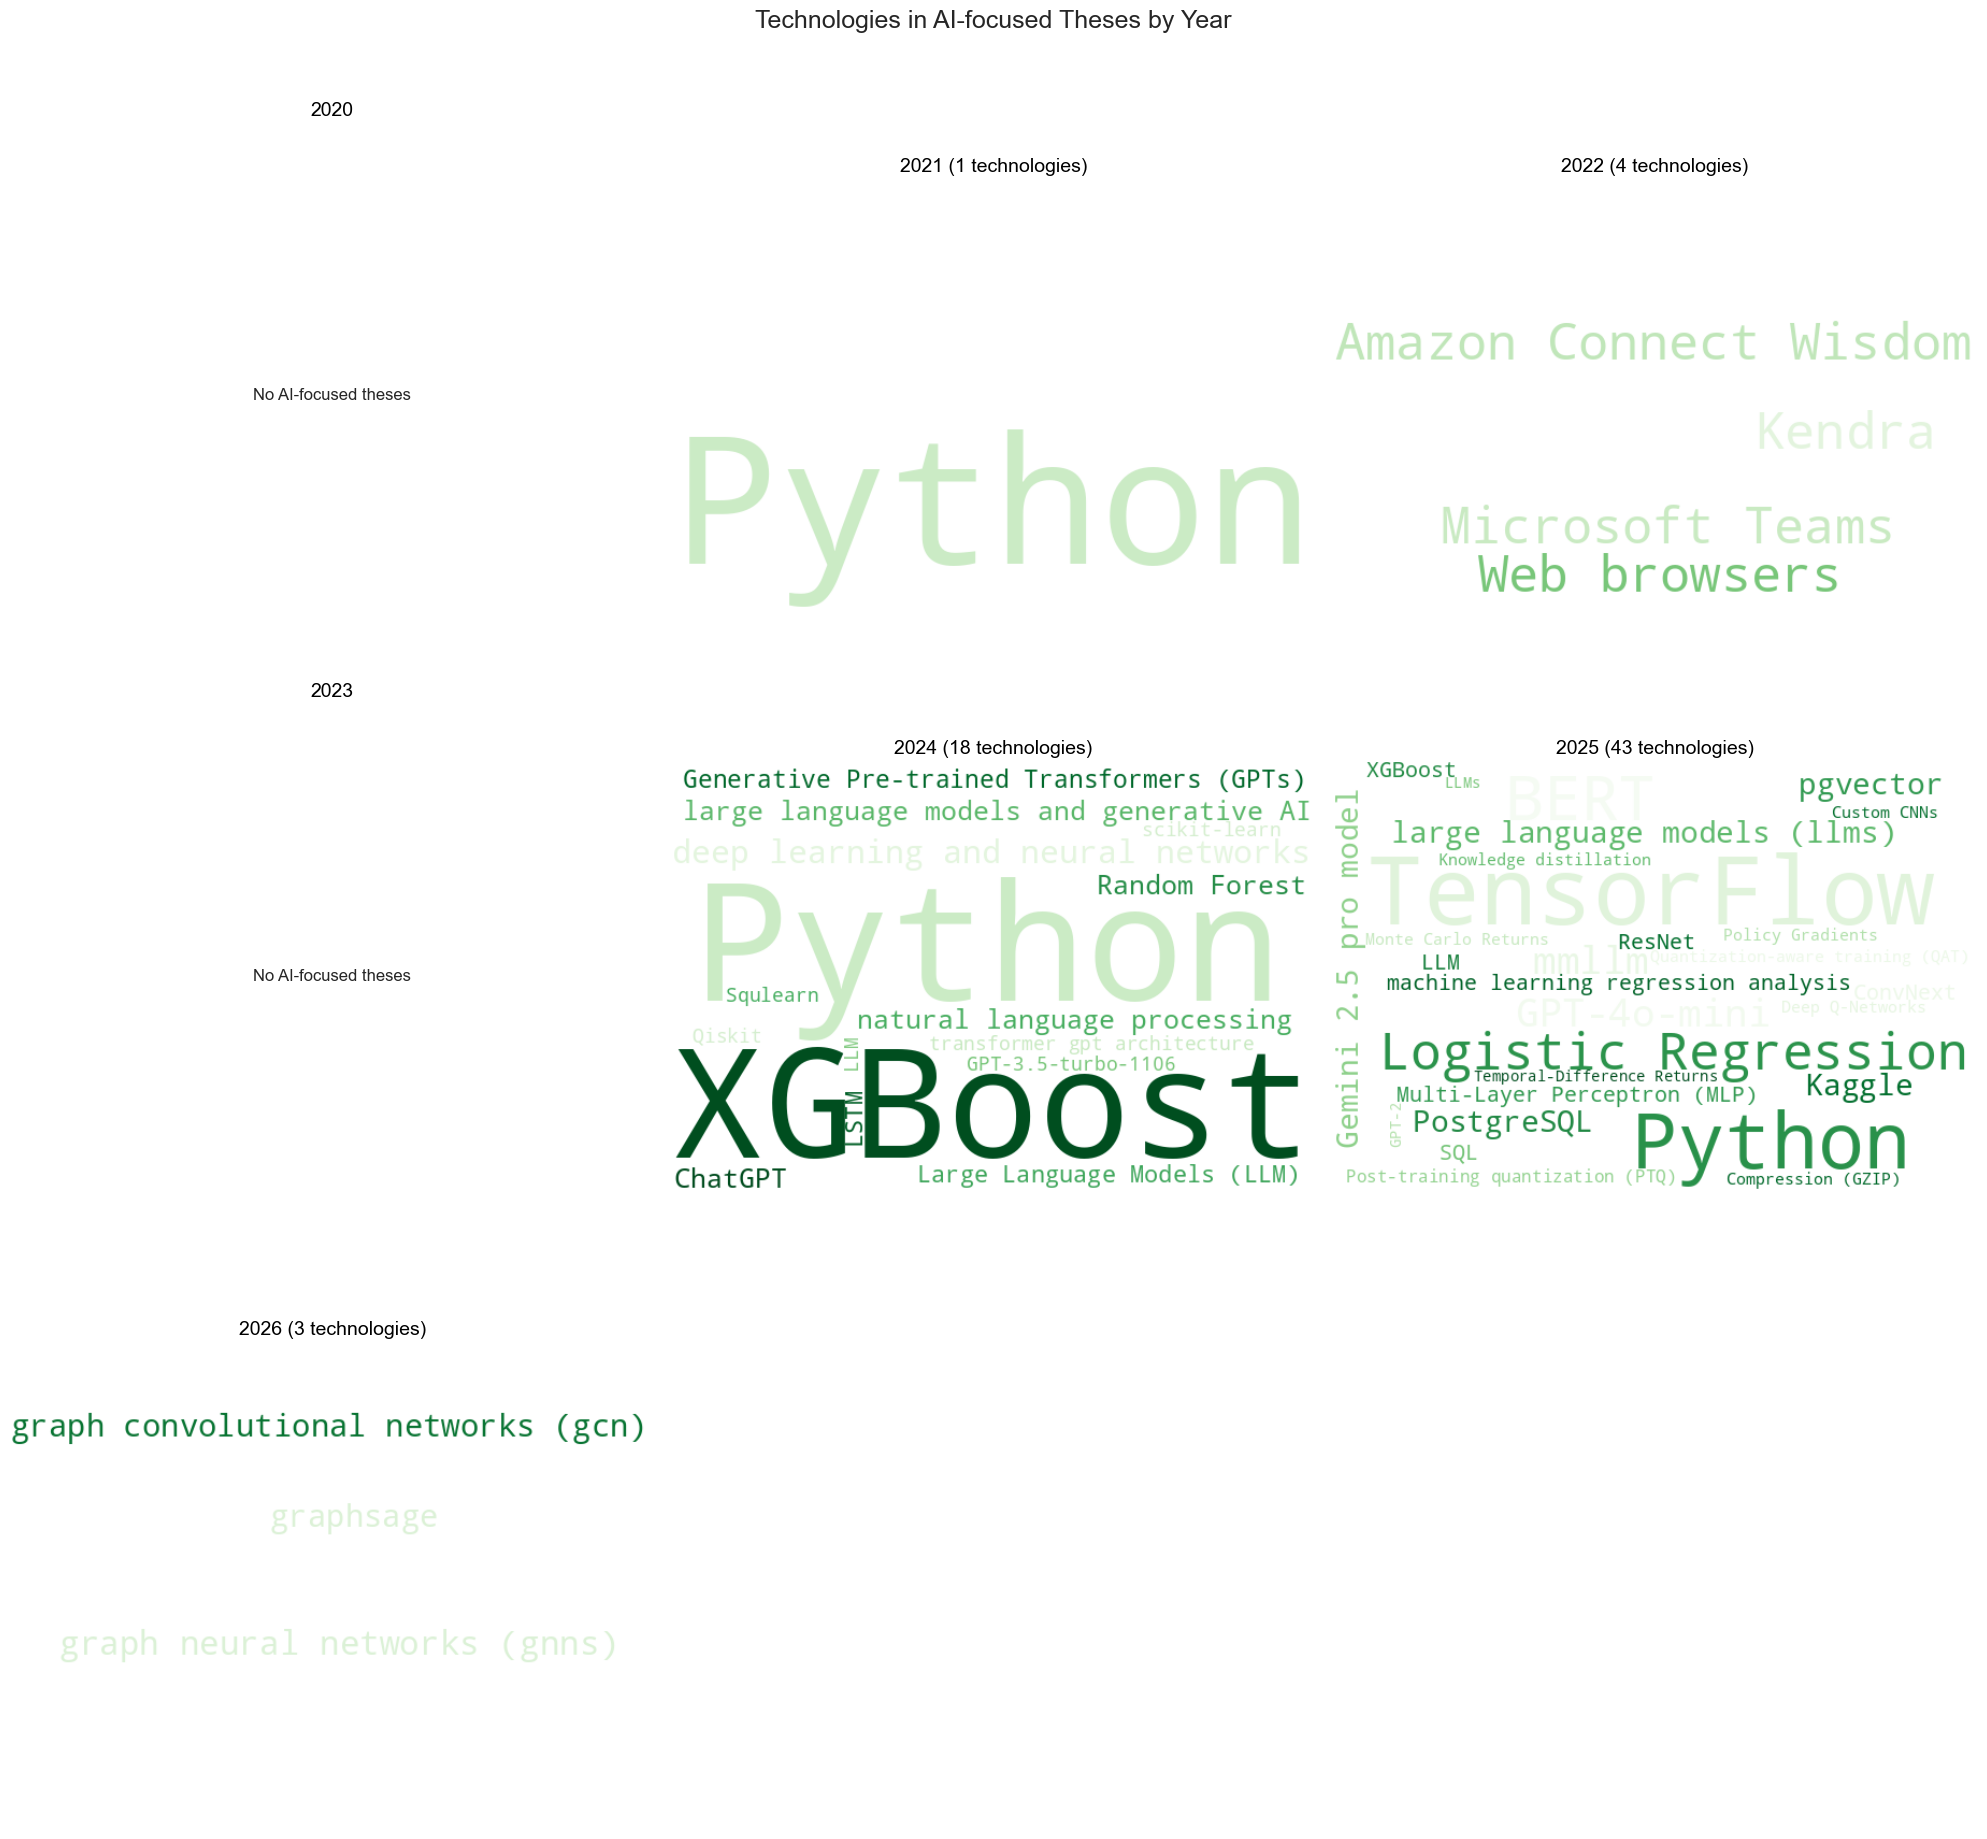

In [101]:
years = sorted(theses_metadata["listing_year"].unique())

# dynamic grid size based on number of years
n_cols = 3
n_rows = math.ceil(len(years) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for idx, year in enumerate(years):
    year_techs = [
        tech
        for techs in theses_metadata[
            (theses_metadata["is_ai_focused"] == True) & 
            (theses_metadata["listing_year"] == year)
        ]["technologies"].dropna()
        if isinstance(techs, list)
        for tech in techs
    ]
    
    ax = axes[idx]
    
    if len(year_techs) == 0:
        ax.text(0.5, 0.5, "No AI-focused theses", ha="center", va="center", fontsize=12)
        ax.set_title(f"{year}", fontsize=14)
        ax.axis("off")
        continue
    
    tech_counts = Counter(year_techs)
    
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap="Greens",
        max_words=30,
        collocations=False
    ).generate_from_frequencies(tech_counts)
    
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.set_title(f"{year} ({len(year_techs)} technologies)", fontsize=14)
    ax.axis("off")

# hide unused subplots
for idx in range(len(years), len(axes)):
    axes[idx].axis("off")

plt.suptitle("Technologies in AI-focused Theses by Year", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

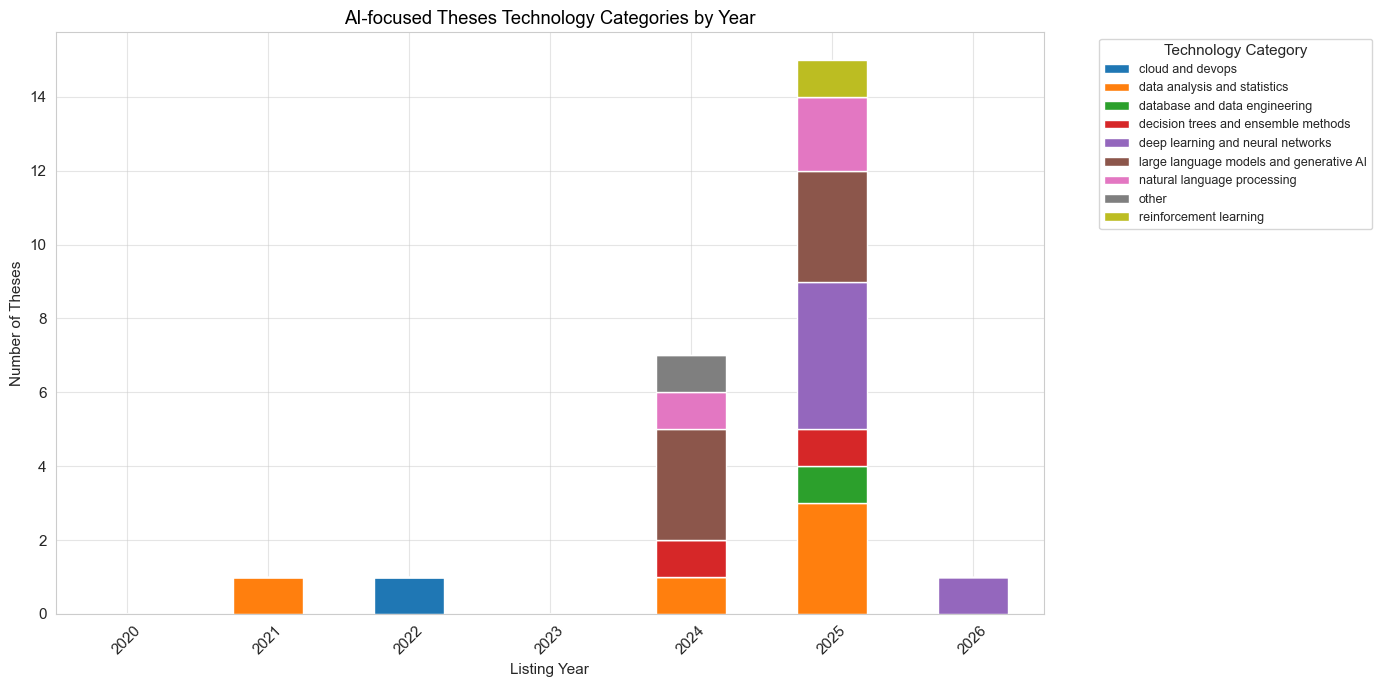

In [107]:
# get all years from full dataset
all_years = sorted(theses_metadata["listing_year"].unique())

# count tech category by year for AI-focused only
ai_tech_by_year = theses_metadata[theses_metadata["is_ai_focused"] == True].groupby(
    ["listing_year", "tech_category"]
).size().unstack(fill_value=0)

# reindex to include all years even if no AI theses that year
ai_tech_by_year = ai_tech_by_year.reindex(all_years, fill_value=0)

colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78"
]

fig, ax = plt.subplots(figsize=(14, 7))

ai_tech_by_year.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors[:len(ai_tech_by_year.columns)],
    edgecolor="white"
)

ax.set_xticklabels(all_years, rotation=45)
ax.set_xlabel("Listing Year")
ax.set_ylabel("Number of Theses")
ax.set_title("AI-focused Theses Technology Categories by Year")
ax.legend(
    title="Technology Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [108]:
theses_metadata.to_csv("theses_metadata_classified_industry_technology.csv", index = False)

# 3. Question – What AI techniquest are most commonly used?
## Conclusion

The analysis reveals a clear evolution in the AI techniques used in bachelor theses, both in 
terms of diversity and sophistication over time.

In the early years (2021–2023), AI techniques were virtually absent or represented by isolated 
cases, with only basic data analysis and cloud-related work appearing. This aligns with the 
finding from Question 1 that almost no AI-focused theses existed before 2024.

From 2024 onwards, a much richer and more diverse set of techniques emerges. In 2024, the 
dominant technologies were **XGBoost**, **Python**, and tools related to **Large Language Models 
(LLMs)** and **Generative Pre-trained Transformers (GPTs)**.
The stacked bar chart confirms that large language models and generative AI was 
the leading technology category in 2024.

By 2025, the landscape broadens significantly with 43 distinct technologies identified — the 
largest and most diverse set across all years. **TensorFlow**, **Python**, **Logistic 
Regression**, and **large language models** feature prominently, alongside more specialized 
techniques such as **ResNet**, **Multi-Layer Perceptron (MLP)**, **knowledge distillation**, 
and **post-training quantization**. This suggests that students are moving beyond surface-level 
application of AI tools toward deeper technical implementations. The stacked bar chart shows 
deep learning and neural networks becoming the dominant category in 2025, overtaking LLMs.

The 2026 data is limited to only 3 technologies (**graph convolutional networks**, 
**GraphSAGE**, and **graph neural networks**), which likely reflects that the 2026 cohort is 
still in the process of submitting theses rather than a genuine shift toward graph-based methods.

Overall, **Python** emerges as the consistent backbone across all years, while the field has 
shifted from classical machine learning methods such as XGBoost and logistic regression in 2024 
toward deep learning, neural networks, and LLM-based approaches in 2025 — reflecting the 
broader trajectory of AI research during this period.

It should be noted that these findings are limited to English-language theses, and the 
concentration of results from 2024–2025 is partially influenced by the Data Analytics programme 
students entering the thesis stage, as discussed in Question 1.

# 4. Question – Is there a relationship between the AI techniques used and the industry area the thesis is applied in?

## Methodology

To explore the relationship between AI techniques and industry application areas, we build 
entirely on the classifications established in Questions 2 and 3. Each AI-focused thesis has 
already been assigned both a **technology category** (e.g. deep learning and neural networks, 
large language models and generative AI, decision trees and ensemble methods) and an **industry 
category** (e.g. data science and analytics, education and research, finance and banking) 
through the Ollama classification pipeline.

To examine the relationship between these two dimensions, we construct a cross-tabulation 
matrix counting how many theses fall into each combination of technology category and industry 
category. This matrix is then visualised as a **heatmap**, allowing patterns and concentrations 
to be identified at a glance — for example, whether LLM-focused theses cluster in education and 
research, or whether decision tree methods are predominantly applied in finance and banking.

The analysis is restricted to the AI-focused subset identified in Question 1 and covers only 
theses for which both a technology category and an industry category were successfully assigned. 
Given the relatively small size of the corpus, the results should be interpreted as indicative 
patterns rather than statistically robust conclusions.

In [111]:
# filter to AI-focused theses with both categories assigned
ai_cross = theses_metadata[
    (theses_metadata["is_ai_focused"] == True) &
    (theses_metadata["tech_category"].notna()) &
    (theses_metadata["industry_category"].notna())
]

# cross-tabulation matrix
cross_tab = pd.crosstab(
    ai_cross["tech_category"],
    ai_cross["industry_category"]
)

print(cross_tab)

industry_category                        business and management  \
tech_category                                                      
cloud and devops                                               0   
data analysis and statistics                                   0   
database and data engineering                                  0   
decision trees and ensemble methods                            1   
deep learning and neural networks                              0   
large language models and generative AI                        0   
natural language processing                                    0   
other                                                          0   
reinforcement learning                                         1   

industry_category                        data science and analytics  \
tech_category                                                         
cloud and devops                                                  0   
data analysis and statistics          

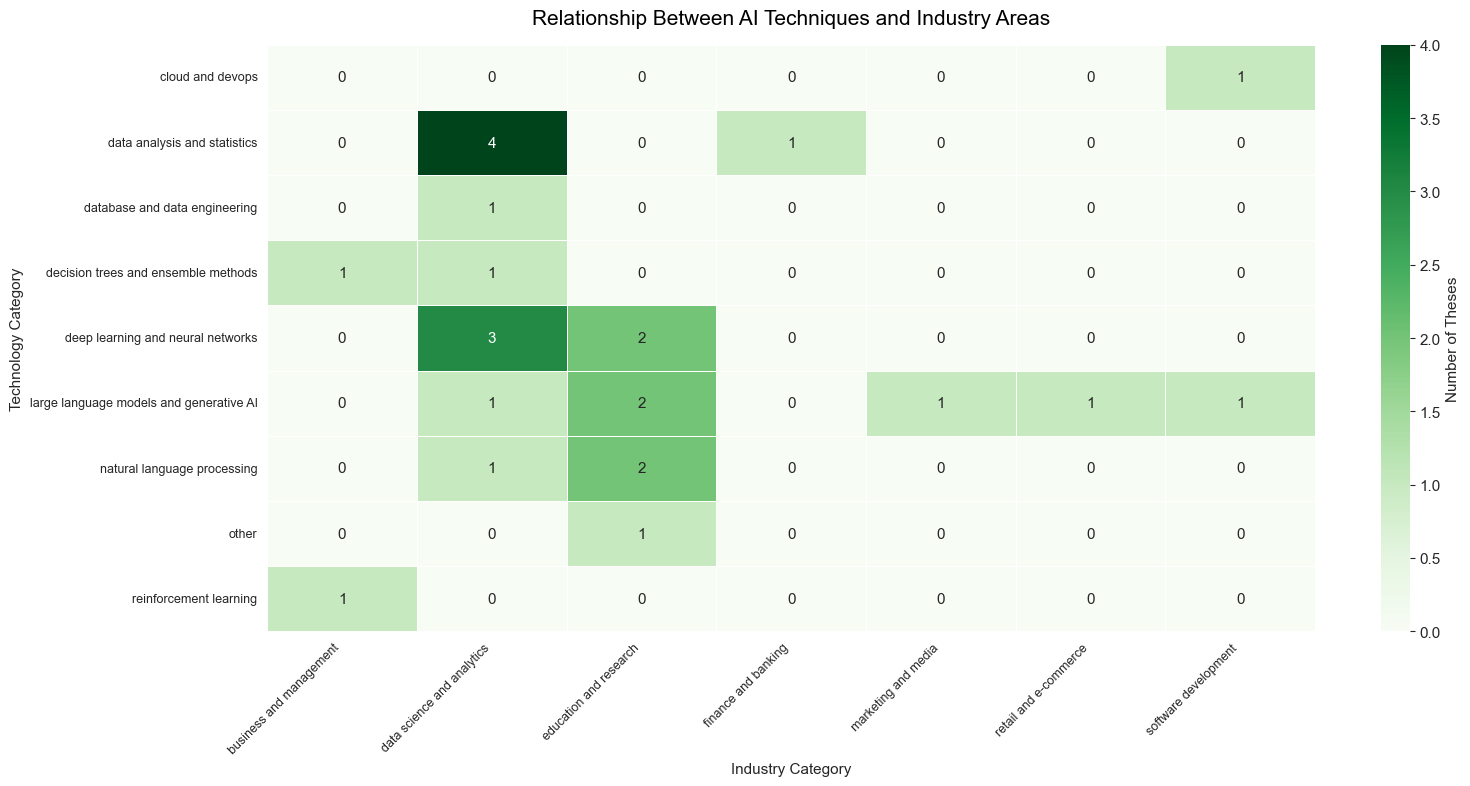

In [113]:
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    cross_tab,
    annot=True,          # show counts in cells
    fmt="d",             # integer format
    cmap="Greens",       # green color scale
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Number of Theses"}
)

ax.set_title("Relationship Between AI Techniques and Industry Areas", fontsize=15, pad=15)
ax.set_xlabel("Industry Category", fontsize=11)
ax.set_ylabel("Technology Category", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# 5. Question – Which departments are driving AI-focused research?

## Methodology

To identify which departments are driving AI-focused research, we use the **department** field 
already available in the thesis metadata. Each thesis is already classified as AI-focused or 
not from Question 1, allowing us to directly compare the volume of AI-focused theses across 
departments.

To add a further dimension, we cross-tabulate department against student programme, revealing 
whether AI research within a department is driven by a single programme or spans across 
multiple programmes. This is visualised as a **stacked bar chart** with one bar per department, 
split by programme, and separated into AI-focused and non-AI-focused theses for comparison.

As with previous questions, the analysis covers only English-language theses and should be 
interpreted with the caveat that departments supervising predominantly Czech-language theses 
may be underrepresented.

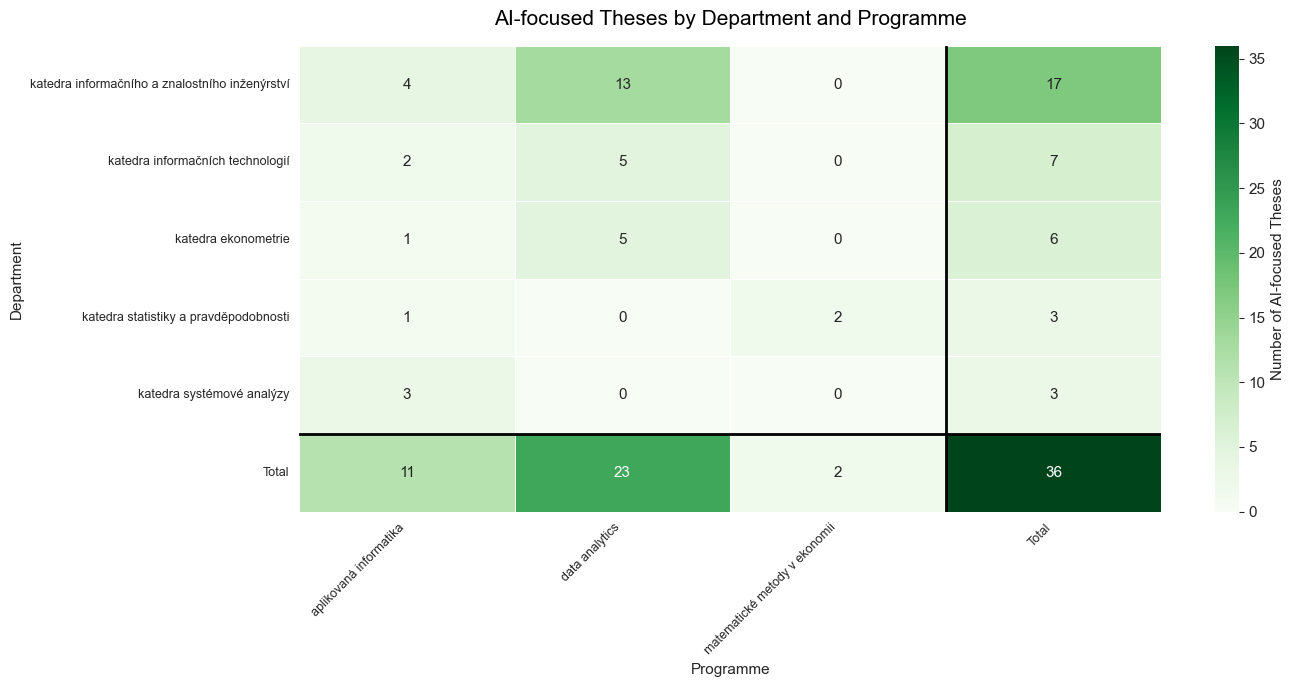

In [119]:
# cross-tabulate department vs programme for AI-focused only
dept_programme = pd.crosstab(
    theses_metadata[theses_metadata["is_ai_focused"] == True]["department"],
    theses_metadata[theses_metadata["is_ai_focused"] == True]["programme"]
)

# add row and column totals
dept_programme["Total"] = dept_programme.sum(axis=1)
dept_programme.loc["Total"] = dept_programme.sum(axis=0)

# sort rows by total (excluding the Total row)
dept_programme = pd.concat([
    dept_programme.drop("Total").sort_values("Total", ascending=False),
    dept_programme.loc[["Total"]]
])

fig, ax = plt.subplots(figsize=(14, 7))

# separate colors for total row/column
mask_total = pd.DataFrame(False, index=dept_programme.index, columns=dept_programme.columns)

sns.heatmap(
    dept_programme,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Number of AI-focused Theses"}
)

# highlight total row and column with darker lines
ax.axhline(len(dept_programme) - 1, color="black", linewidth=2)
ax.axvline(len(dept_programme.columns) - 1, color="black", linewidth=2)

ax.set_title("AI-focused Theses by Department and Programme", fontsize=15, pad=15)
ax.set_xlabel("Programme", fontsize=11)
ax.set_ylabel("Department", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

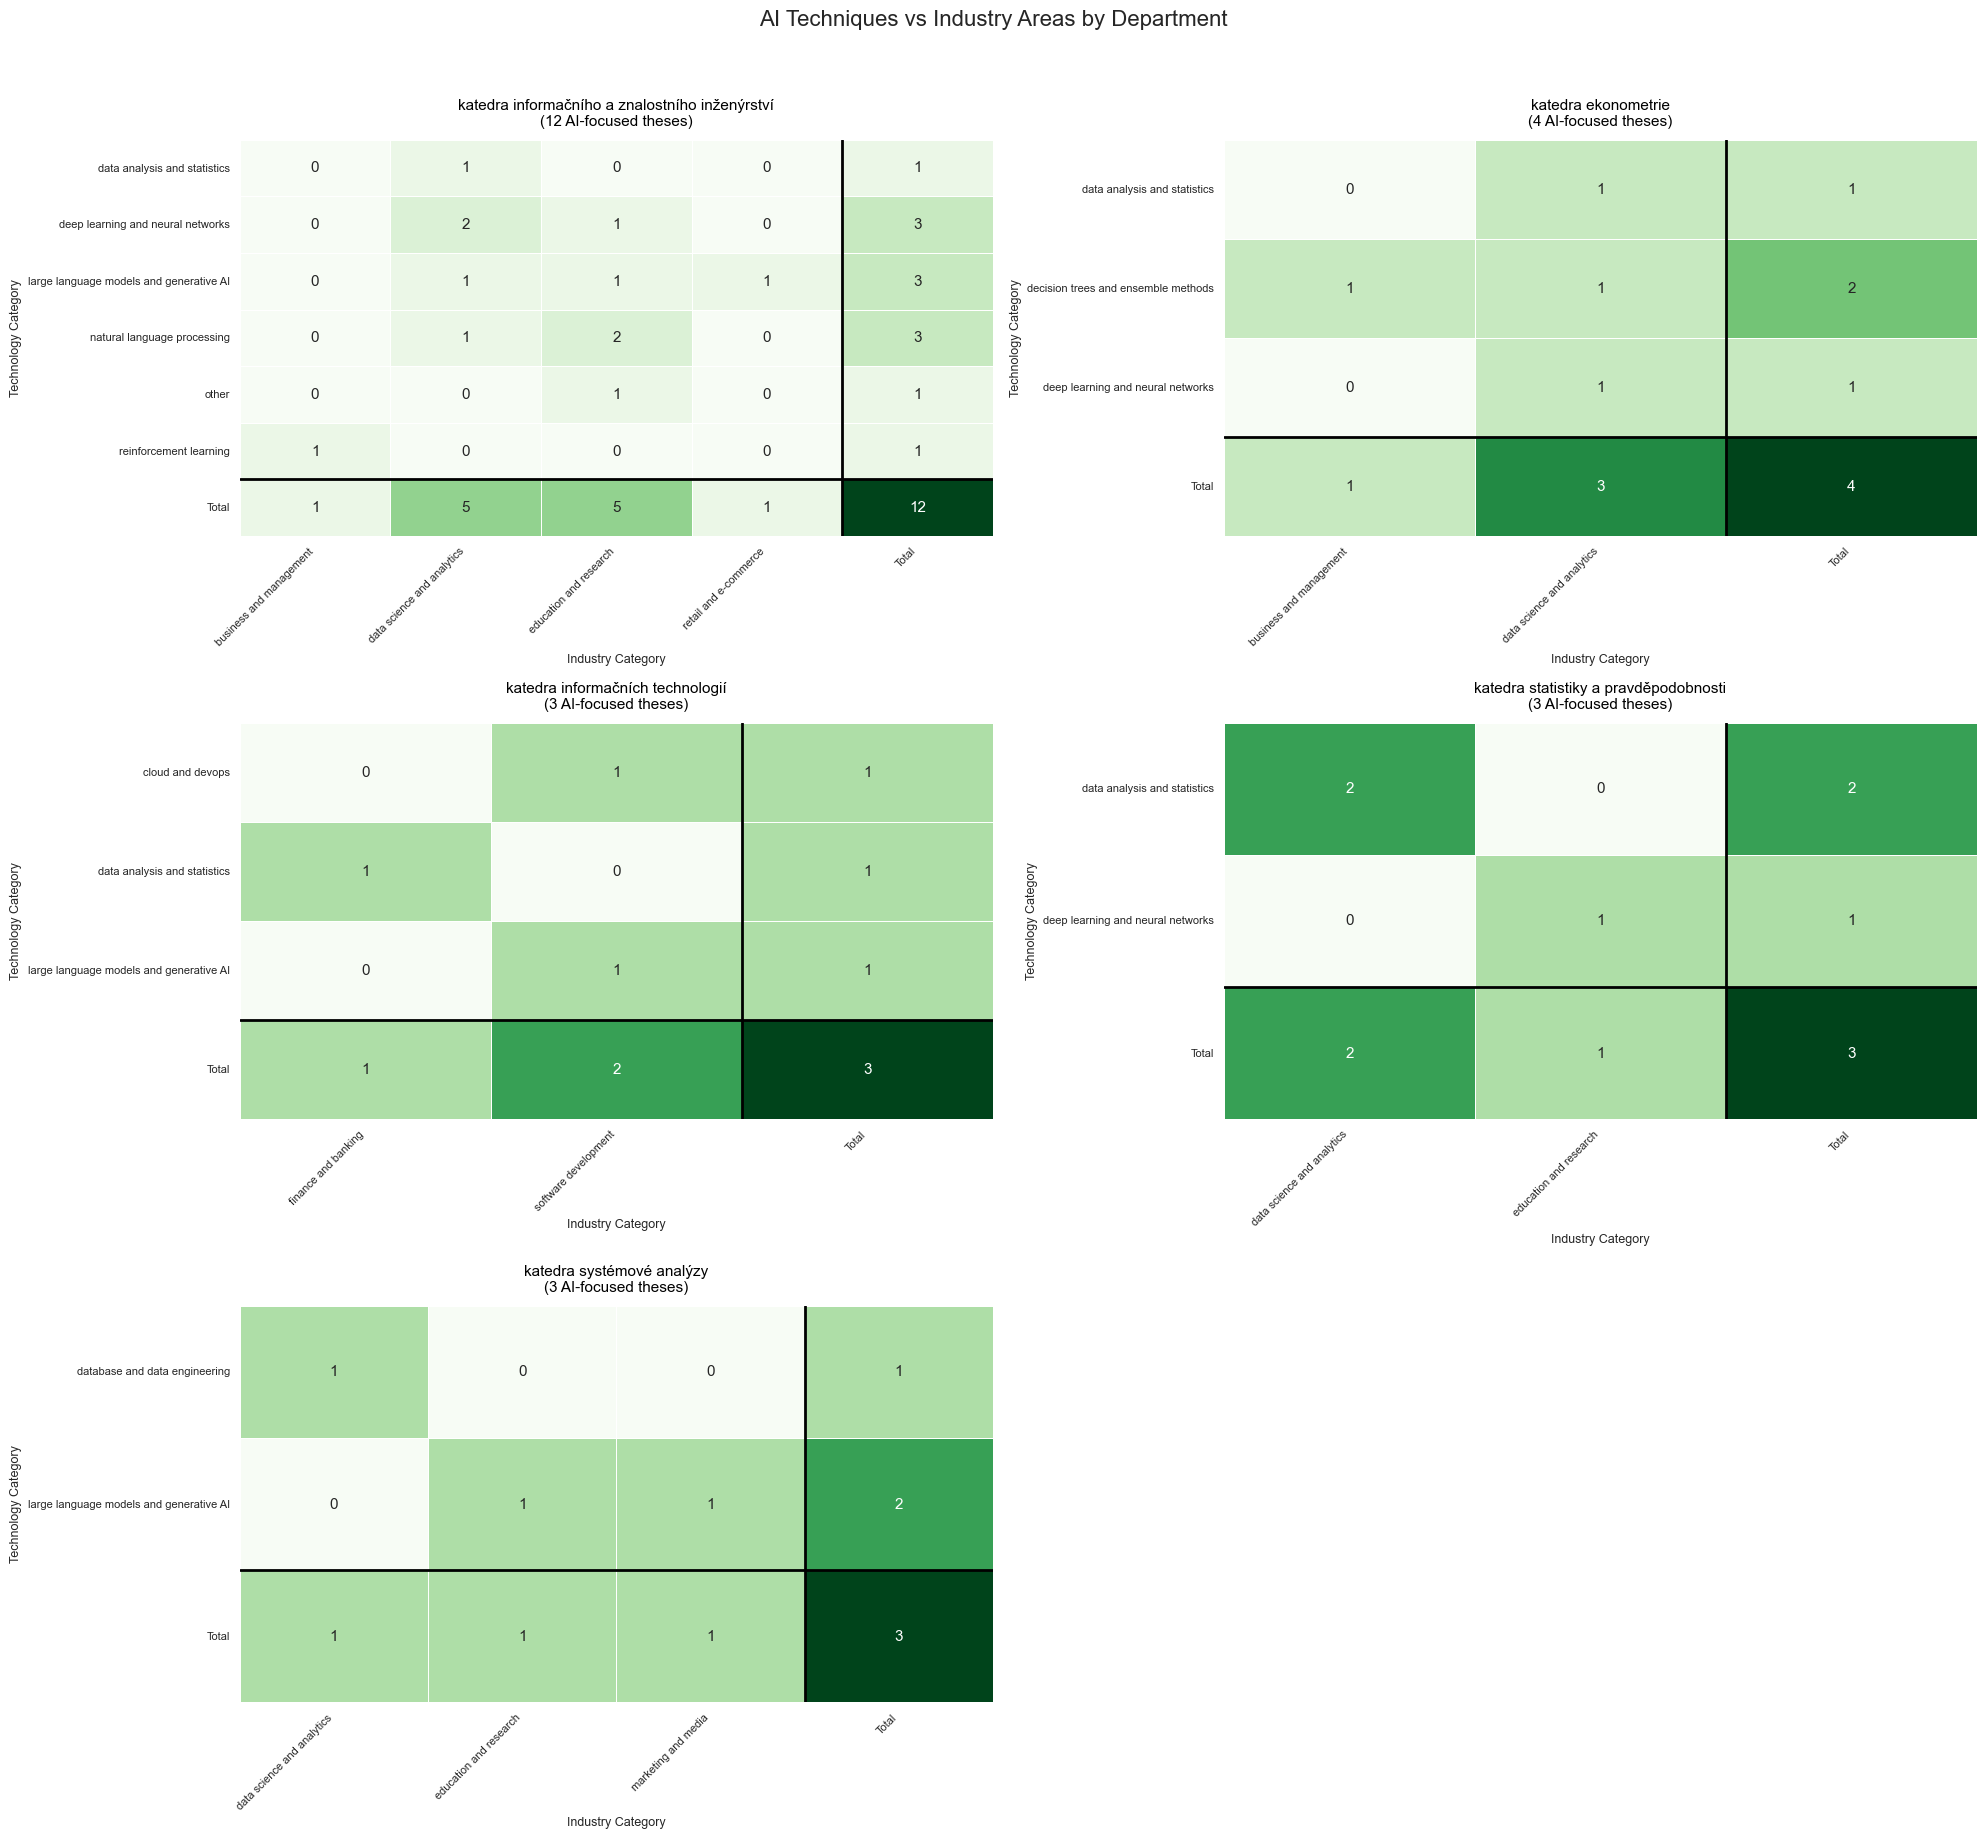

In [123]:
# get departments with AI-focused theses
ai_dept = theses_metadata[
    (theses_metadata["is_ai_focused"] == True) &
    (theses_metadata["tech_category"].notna()) &
    (theses_metadata["industry_category"].notna())
]

departments = ai_dept["department"].value_counts()
departments = departments[departments > 0].index.tolist()

# grid size
n_cols = 2
n_rows = math.ceil(len(departments) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for idx, dept in enumerate(departments):
    dept_data = ai_dept[ai_dept["department"] == dept]
    
    if len(dept_data) == 0:
        axes[idx].axis("off")
        continue
    
    # cross-tab tech vs industry for this department
    cross = pd.crosstab(
        dept_data["tech_category"],
        dept_data["industry_category"]
    )
    
    # add totals
    cross["Total"] = cross.sum(axis=1)
    cross.loc["Total"] = cross.sum(axis=0)
    
    sns.heatmap(
        cross,
        annot=True,
        fmt="d",
        cmap="Greens",
        linewidths=0.5,
        linecolor="white",
        ax=axes[idx],
        cbar=False
    )
    
    # highlight total row and column
    axes[idx].axhline(len(cross) - 1, color="black", linewidth=2)
    axes[idx].axvline(len(cross.columns) - 1, color="black", linewidth=2)
    
    axes[idx].set_title(f"{dept}\n({len(dept_data)} AI-focused theses)", fontsize=11, pad=10)
    axes[idx].set_xlabel("Industry Category", fontsize=9)
    axes[idx].set_ylabel("Technology Category", fontsize=9)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right", fontsize=8)
    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=8)

# hide unused subplots
for idx in range(len(departments), len(axes)):
    axes[idx].axis("off")

plt.suptitle("AI Techniques vs Industry Areas by Department", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Conclusion

The heatmap clearly shows that AI-focused research is not driven equally across departments,
it is concentrated in a small number of units, with **Katedra informačního a znalostního 
inženýrství** leading significantly with 17 AI-focused theses, followed by **Katedra 
informačních technologií** (7) and **Katedra ekonometrie** (6). The remaining departments, mainly
Katedra statistiky a pravděpodobnosti and Katedra systémové analýzy, each contribute only 3 
theses, suggesting AI research has not yet become a central theme in their supervised work.

The breakdown by programme reveals that the dominance of Katedra informačního a znalostního 
inženýrství is driven almost entirely by the **Data Analytics** programme (13 out of 17 
theses), reinforcing the finding from Question 1 that the growth of AI research at the faculty 
is closely tied to this single programme. Aplikovaná Informatika theses are more evenly 
distributed across departments, suggesting a broader base of AI supervision within that 
programme.

The per-department technique and industry breakdown shows meaningful differences in research 
focus. Katedra informačního a znalostního inženýrství supervises work spanning deep learning, 
natural language processing, and large language models applied across data science, education, 
and business domains. Katedra ekonometrie focuses more narrowly on decision trees and ensemble 
methods in a business and analytics context, reflecting its quantitative orientation. Katedra 
informačních technologií shows a concentration in software development and finance, while 
Katedra statistiky a pravděpodobnosti focuses on data analysis and statistics as expected 
given its disciplinary background.


# 6. Question – What are opinions and feelings of students about their bachalors work? Their motivation and final conclusion of their work?

## Methodology

To explore the subjective dimension of bachelor theses, we move beyond topic and technique 
classification and focus on the human element — what motivated students to choose their topic, 
how they reflect on their work, and what conclusions they draw.

Since full thesis texts are available, we target two specific sections of each document:
the **introduction**, which typically contains the student's motivation and rationale for 
choosing the topic, and the **conclusion**, which contains their final reflections, results, 
and self-assessment. Rather than processing the entire thesis, extracting these sections 
reduces noise and focuses the analysis on the most personally expressive parts of the document.

A locally running **Ollama LLM** is prompted to analyse each extracted section and return 
structured information covering the student's motivation, their overall sentiment toward the 
work, key conclusions drawn, and any expressed challenges or limitations. Sentiment is 
classified into positive, neutral, and negative categories to allow aggregation and comparison 
across theses and over time.

The analysis is performed on all theses for which full text was successfully loaded, not just 
the AI-focused subset, allowing for a broader view of student experience across programmes and 
years.

In [149]:
theses_metadata = pd.read_csv("theses_metadata_classified_industry_technology.csv")

In [165]:
def clean_pdf_text(text):
    """Clean raw PDF text of noise."""
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return None
    text = str(text)
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\b\d{1,3}\b', '', text)  # remove page numbers
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # remove non-ASCII
    return text.strip()

def find_section(text, section_patterns):
    """Find section start index using multiple patterns."""
    for pattern in section_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.start(), match.end()
    return None, None

def extract_until_new_page(text, start):
    """Extract text from start until next page break or large whitespace gap."""
    section_text = text[start:]
    
    # look for page break indicators
    page_break = re.search(
        r'(\f|'           # form feed character
        r'\n{3,}|'        # multiple newlines
        r'\s{10,})',      # large whitespace gap
        section_text
    )
    
    if page_break:
        return section_text[:page_break.start()].strip()
    return section_text.strip()

def extract_intro_and_conclusion(raw_text, fallback_chars=4000):
    if raw_text is None or (isinstance(raw_text, float) and np.isnan(raw_text)):
        return None, None
    
    raw_text = str(raw_text)
    
    # --- introduction patterns ---
    intro_patterns = [
        r'\bIntroduction\b',
        r'\b1[\.\s]+Introduction\b',
        r'\bIntroduction and [Mm]otivation\b',
        r'\bBackground\b',
        r'\b1[\.\s]+Background\b',
    ]
    
    # --- conclusion patterns ---
    conclusion_patterns = [
        r'\bConclusion\b',
        r'\bConclusions\b',
        r'\bConclusion and [Ff]uture\b',
        r'\bSummary\b',
        r'\bFinal [Rr]emarks\b',
        r'\bClosing [Rr]emarks\b',
    ]
    
    # --- try to find introduction ---
    intro_start, intro_end = find_section(raw_text, intro_patterns)
    
    if intro_start is not None:
        # extract from header end until page break
        raw_intro = extract_until_new_page(raw_text, intro_end)
        # if too short try taking more
        if len(raw_intro) < 200:
            raw_intro = raw_text[intro_end:intro_end + fallback_chars]
        intro = clean_pdf_text(raw_intro)
    else:
        # fallback: take first 4000 chars of clean text
        intro = clean_pdf_text(raw_text[:fallback_chars])
    
    # --- try to find conclusion ---
    # search from the second half of the document to avoid false matches
    halfway = len(raw_text) // 2
    conclusion_start, conclusion_end = find_section(raw_text[halfway:], conclusion_patterns)
    
    if conclusion_start is not None:
        # adjust index to full text
        conclusion_end_full = halfway + conclusion_end
        raw_conclusion = extract_until_new_page(raw_text, conclusion_end_full)
        if len(raw_conclusion) < 200:
            raw_conclusion = raw_text[conclusion_end_full:conclusion_end_full + fallback_chars]
        conclusion = clean_pdf_text(raw_conclusion)
    else:
        # fallback: take last 4000 chars of clean text
        conclusion = clean_pdf_text(raw_text[-fallback_chars:])
    
    return intro, conclusion


# run on raw (uncleaned) text for best results
theses_metadata[["intro_text", "conclusion_text"]] = theses_metadata["full_text"].apply(
    lambda x: pd.Series(
        extract_intro_and_conclusion(x),
        index=["intro_text", "conclusion_text"]
    )
)

print(f"Intro extracted:      {theses_metadata['intro_text'].notna().sum()}/{len(theses_metadata)}")
print(f"Conclusion extracted: {theses_metadata['conclusion_text'].notna().sum()}/{len(theses_metadata)}")

# spot check
print("\n--- INTRO SAMPLE ---")
print(theses_metadata["intro_text"].dropna().iloc[0][:500])
print("\n--- CONCLUSION SAMPLE ---")
print(theses_metadata["conclusion_text"].dropna().iloc[0][:500])

theses_metadata.to_csv("theses_with_sentiment.csv", index=False)

Intro extracted:      120/162
Conclusion extracted: 120/162

--- INTRO SAMPLE ---
..........................................................................................................................   Development Process Plan ................................................................................................   Domain-Driven Design (DDD) ..........................................................................................  . Why DDD? ...................................................................................................................  . Ub

--- CONCLUSION SAMPLE ---
This bachelor s thesis covered some basic theory about domain-driven design and has described written framework internals and sample application implementations. Framework v1. has limited functionality, but it was enough to successfully build an application using the DDD approach. Future improvements could cover some inner tooling to MongoDB migrations handling or extension points for da

In [172]:
def sanitize_for_prompt(text, max_chars=4000):
    """Clean text before injecting into prompt to avoid JSON parsing issues."""
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    text = str(text)[:max_chars]
    # remove characters that break JSON
    text = text.replace('"', "'")
    text = text.replace('\\', ' ')
    text = text.replace('\n', ' ')
    text = text.replace('\r', ' ')
    text = re.sub(r'[^\x20-\x7E]', ' ', text)  # keep only printable ASCII
    return text.strip()

def parse_llm_json(content):
    """Try multiple strategies to parse potentially malformed JSON."""
    # clean markdown backticks
    content = content.strip()
    content = re.sub(r'^```json\s*', '', content)
    content = re.sub(r'^```\s*', '', content)
    content = re.sub(r'\s*```$', '', content)
    content = content.strip()
    
    # try direct parse first
    try:
        return json.loads(content)
    except json.JSONDecodeError:
        pass
    
    # try fixing common issues
    try:
        # replace smart quotes
        content = content.replace('\u2018', "'").replace('\u2019', "'")
        content = content.replace('\u201c', "'").replace('\u201d', "'")
        # remove control characters
        content = re.sub(r'[\x00-\x1f\x7f]', ' ', content)
        return json.loads(content)
    except json.JSONDecodeError:
        pass
    
    # try extracting just the JSON object
    try:
        match = re.search(r'\{.*\}', content, re.DOTALL)
        if match:
            return json.loads(match.group())
    except json.JSONDecodeError:
        pass
    
    # last resort - extract fields manually with regex
    try:
        result = {
            "motivation": re.search(r'"motivation"\s*:\s*"([^"]*)"', content),
            "sentiment": re.search(r'"sentiment"\s*:\s*"([^"]*)"', content),
            "sentiment_reasoning": re.search(r'"sentiment_reasoning"\s*:\s*"([^"]*)"', content),
            "student_satisfaction": re.search(r'"student_satisfaction"\s*:\s*"([^"]*)"', content),
            "confidence": re.search(r'"confidence"\s*:\s*([\d.]+)', content),
        }
        return {
            "motivation": result["motivation"].group(1) if result["motivation"] else None,
            "sentiment": result["sentiment"].group(1) if result["sentiment"] else None,
            "sentiment_reasoning": result["sentiment_reasoning"].group(1) if result["sentiment_reasoning"] else None,
            "key_conclusions": [],
            "challenges_mentioned": [],
            "student_satisfaction": result["student_satisfaction"].group(1) if result["student_satisfaction"] else None,
            "confidence": float(result["confidence"].group(1)) if result["confidence"] else None,
        }
    except Exception:
        pass
    
    return None


def analyse_student_sentiment(intro, conclusion, abstract):
    try:
        if intro is None and conclusion is None:
            return None

        intro_str = sanitize_for_prompt(intro)
        conclusion_str = sanitize_for_prompt(conclusion)
        abstract_str = sanitize_for_prompt(abstract)

        prompt = f"""You are analysing a bachelor thesis. Respond ONLY with a JSON object.

Introduction: {intro_str}
Conclusion: {conclusion_str}
Abstract: {abstract_str}

JSON format:
{{
    "motivation": "one sentence, use only basic ASCII characters, no special punctuation",
    "sentiment": "positive or neutral or negative",
    "sentiment_reasoning": "one sentence, use only basic ASCII characters",
    "key_conclusions": ["conclusion 1", "conclusion 2", "conclusion 3"],
    "challenges_mentioned": ["challenge 1", "challenge 2"],
    "student_satisfaction": "satisfied or neutral or dissatisfied",
    "confidence": 0.95
}}"""

        response = ollama.chat(
            model="llama3.2",
            messages=[{"role": "user", "content": prompt}]
        )

        content = response["message"]["content"]
        result = parse_llm_json(content)
        return result

    except Exception as e:
        print(f"Error: {e}")
        return None

In [173]:
sentiment_results = theses_metadata.apply(
    lambda row: analyse_student_sentiment(
        row["intro_text"],
        row["conclusion_text"],
        row["abstract"]
    ),
    axis=1
)

# unpack results into columns
theses_metadata["motivation"] = sentiment_results.apply(
    lambda x: x["motivation"] if x and "motivation" in x else None
)
theses_metadata["sentiment"] = sentiment_results.apply(
    lambda x: x["sentiment"] if x and "sentiment" in x else None
)
theses_metadata["sentiment_reasoning"] = sentiment_results.apply(
    lambda x: x["sentiment_reasoning"] if x and "sentiment_reasoning" in x else None
)
theses_metadata["key_conclusions"] = sentiment_results.apply(
    lambda x: x["key_conclusions"] if x and "key_conclusions" in x else []
)
theses_metadata["challenges_mentioned"] = sentiment_results.apply(
    lambda x: x["challenges_mentioned"] if x and "challenges_mentioned" in x else []
)
theses_metadata["student_satisfaction"] = sentiment_results.apply(
    lambda x: x["student_satisfaction"] if x and "student_satisfaction" in x else None
)

theses_metadata.to_csv("theses_with_sentiment.csv", index=False)
print("Done")

Done


In [174]:
print("Sentiment distribution:")
print(theses_metadata["sentiment"].value_counts())

print("\nStudent satisfaction distribution:")
print(theses_metadata["student_satisfaction"].value_counts())

# breakdown by year
print("\nSentiment by year:")
print(pd.crosstab(theses_metadata["listing_year"], theses_metadata["sentiment"]))

Sentiment distribution:
sentiment
positive    112
neutral      42
Name: count, dtype: int64

Student satisfaction distribution:
student_satisfaction
satisfied                                                  125
neutral                                                     27
dissatisfied                                                 2
dissatisfied with some aspects of Freshlabels' approach      1
Name: count, dtype: int64

Sentiment by year:
sentiment     neutral  positive
listing_year                   
2020                4         7
2021                1         8
2022                5         7
2023                4        15
2024                4        18
2025                7        29
2026               17        28


In [175]:
print("Example of the first student")
print(theses_metadata.iloc[0]["motivation"])
print(theses_metadata.iloc[0]["sentiment"])
print(theses_metadata.iloc[0]["sentiment_reasoning"])
print(theses_metadata.iloc[0]["key_conclusions"])
print(theses_metadata.iloc[0]["challenges_mentioned"])
print(theses_metadata.iloc[0]["student_satisfaction"])

Example of the first student
create framework to speed up DDD development on .NET Core with MongoDB
positive
framework covers essential DDD concepts and provides a clear implementation path
[]
[]
satisfied


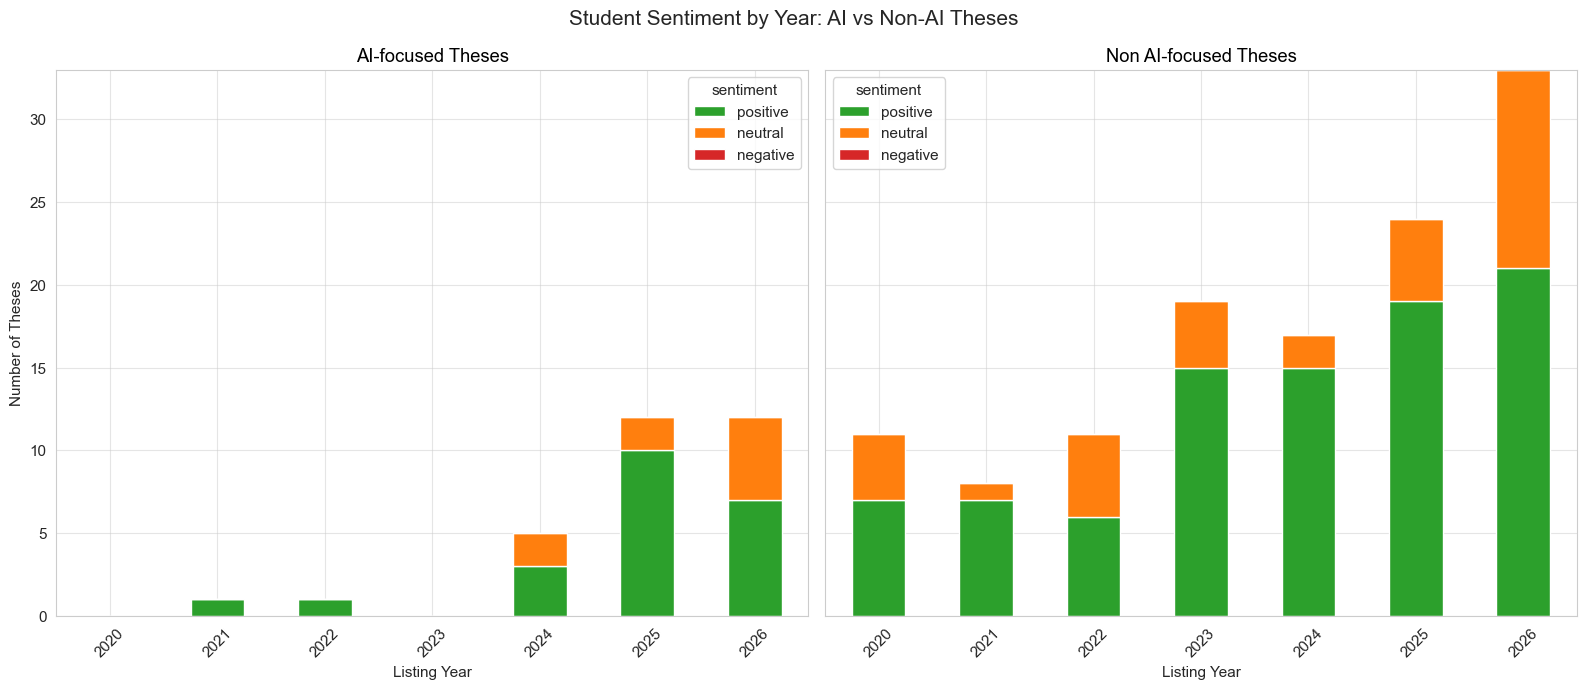

In [178]:
# get all years from full dataset
all_years = sorted(theses_metadata["listing_year"].unique())

all_sentiments = ["positive", "neutral", "negative"]

# AI theses only
ai_sentiment = pd.crosstab(
    theses_metadata.loc[theses_metadata["is_ai_focused"] == True, "listing_year"],
    theses_metadata.loc[theses_metadata["is_ai_focused"] == True, "sentiment"]
).reindex(all_years, fill_value=0)

# ensure all sentiment columns exist
for s in all_sentiments:
    if s not in ai_sentiment.columns:
        ai_sentiment[s] = 0
ai_sentiment = ai_sentiment[all_sentiments]

# Non-AI theses
non_ai_sentiment = pd.crosstab(
    theses_metadata.loc[theses_metadata["is_ai_focused"] == False, "listing_year"],
    theses_metadata.loc[theses_metadata["is_ai_focused"] == False, "sentiment"]
).reindex(all_years, fill_value=0)

for s in all_sentiments:
    if s not in non_ai_sentiment.columns:
        non_ai_sentiment[s] = 0
non_ai_sentiment = non_ai_sentiment[all_sentiments]

colors = {
    "positive": "#2ca02c",
    "neutral": "#ff7f0e",
    "negative": "#d62728"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

ai_sentiment.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[colors[s] for s in all_sentiments],
    edgecolor="white"
)
axes[0].set_title("AI-focused Theses")
axes[0].set_xlabel("Listing Year")
axes[0].set_ylabel("Number of Theses")
axes[0].set_xticklabels(all_years, rotation=45)

non_ai_sentiment.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[colors[s] for s in all_sentiments],
    edgecolor="white"
)
axes[1].set_title("Non AI-focused Theses")
axes[1].set_xlabel("Listing Year")
axes[1].set_xticklabels(all_years, rotation=45)

plt.suptitle("Student Sentiment by Year: AI vs Non-AI Theses", fontsize=15)
plt.tight_layout()
plt.show()

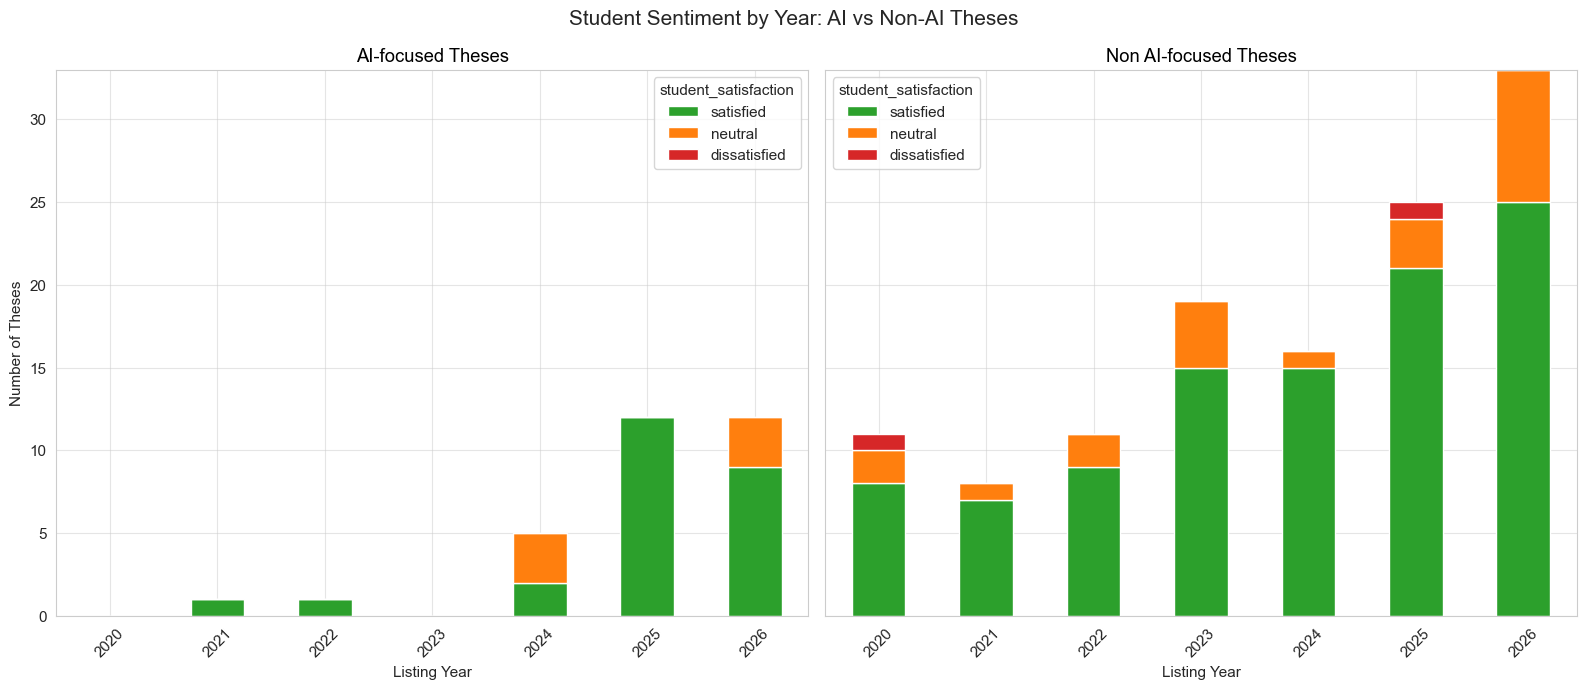

In [182]:
# get all years from full dataset
all_years = sorted(theses_metadata["listing_year"].unique())

all_satisfactions = ["satisfied", "neutral", "dissatisfied"]

# AI theses only
ai_sentiment = pd.crosstab(
    theses_metadata.loc[theses_metadata["is_ai_focused"] == True, "listing_year"],
    theses_metadata.loc[theses_metadata["is_ai_focused"] == True, "student_satisfaction"]
).reindex(all_years, fill_value=0)

# ensure all sentiment columns exist
for s in all_satisfactions:
    if s not in ai_sentiment.columns:
        ai_sentiment[s] = 0
ai_sentiment = ai_sentiment[all_satisfactions]

# Non-AI theses
non_ai_sentiment = pd.crosstab(
    theses_metadata.loc[theses_metadata["is_ai_focused"] == False, "listing_year"],
    theses_metadata.loc[theses_metadata["is_ai_focused"] == False, "student_satisfaction"]
).reindex(all_years, fill_value=0)

for s in all_satisfactions:
    if s not in non_ai_sentiment.columns:
        non_ai_sentiment[s] = 0
non_ai_sentiment = non_ai_sentiment[all_satisfactions]

colors = {
    "satisfied": "#2ca02c",
    "neutral": "#ff7f0e",
    "dissatisfied": "#d62728"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

ai_sentiment.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[colors[s] for s in all_satisfactions],
    edgecolor="white"
)
axes[0].set_title("AI-focused Theses")
axes[0].set_xlabel("Listing Year")
axes[0].set_ylabel("Number of Theses")
axes[0].set_xticklabels(all_years, rotation=45)

non_ai_sentiment.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[colors[s] for s in all_satisfactions],
    edgecolor="white"
)
axes[1].set_title("Non AI-focused Theses")
axes[1].set_xlabel("Listing Year")
axes[1].set_xticklabels(all_years, rotation=45)

plt.suptitle("Student Sentiment by Year: AI vs Non-AI Theses", fontsize=15)
plt.tight_layout()
plt.show()

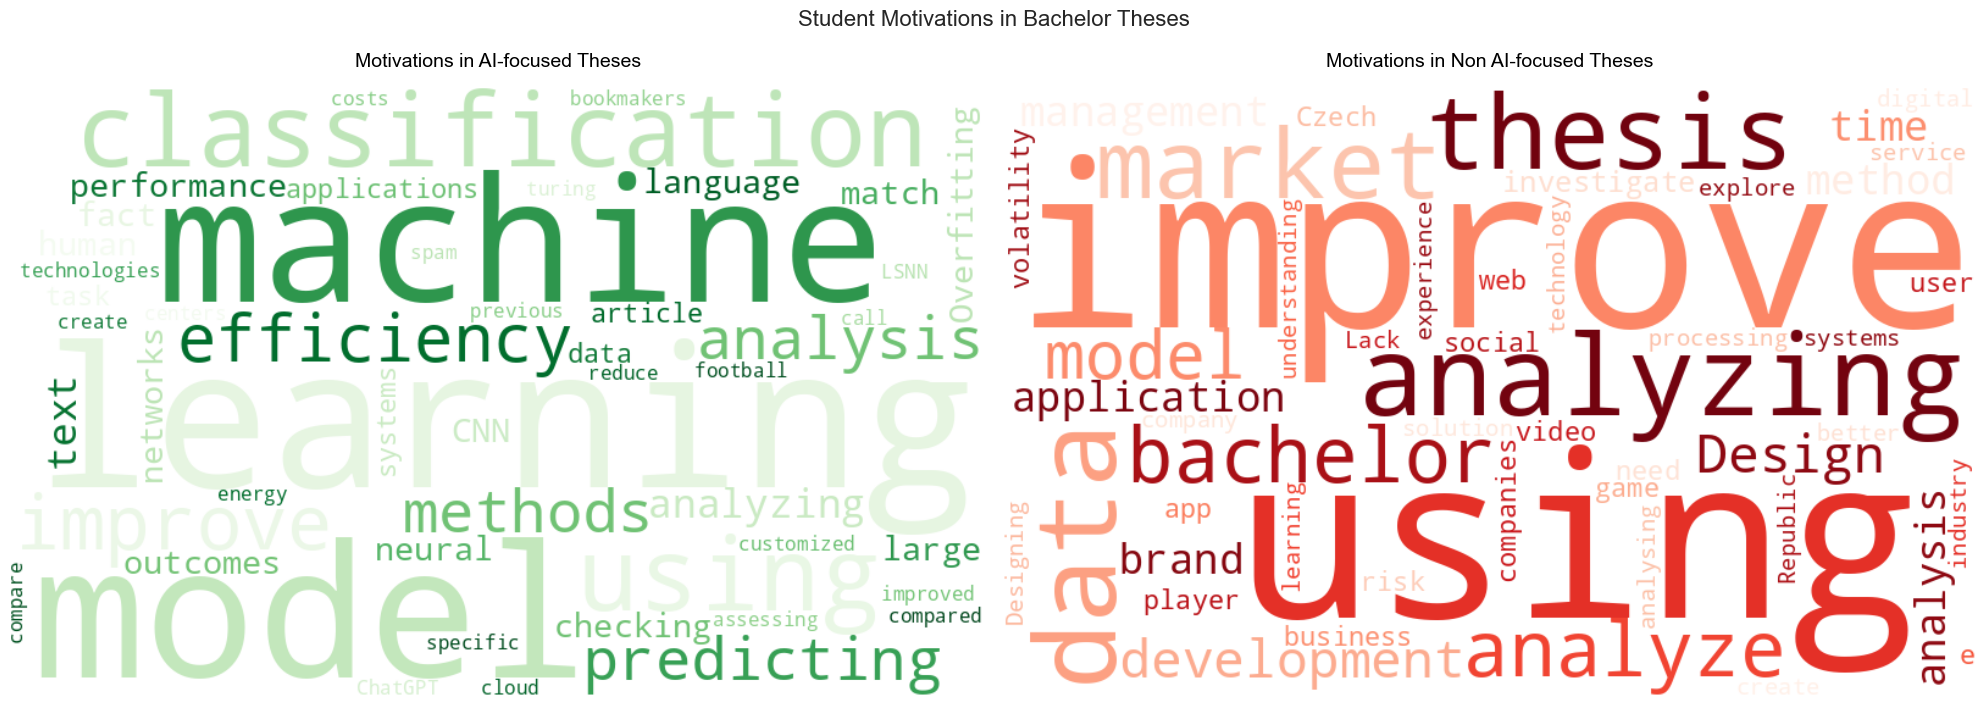

In [188]:
def get_motivations_text(df):
    return " ".join(df["motivation"].dropna().astype(str).tolist())

ai_text = get_motivations_text(theses_metadata[theses_metadata["is_ai_focused"] == True])
non_ai_text = get_motivations_text(theses_metadata[theses_metadata["is_ai_focused"] == False])

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- AI focused ---
wordcloud_ai = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="Greens",
    max_words=50,
    collocations=False
).generate(ai_text)

axes[0].imshow(wordcloud_ai, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Motivations in AI-focused Theses", fontsize=14, pad=15)

# --- Non AI focused ---
wordcloud_non_ai = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="Reds",
    max_words=50,
    collocations=False
).generate(non_ai_text)

axes[1].imshow(wordcloud_non_ai, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Motivations in Non AI-focused Theses", fontsize=14, pad=15)

plt.suptitle("Student Motivations in Bachelor Theses", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

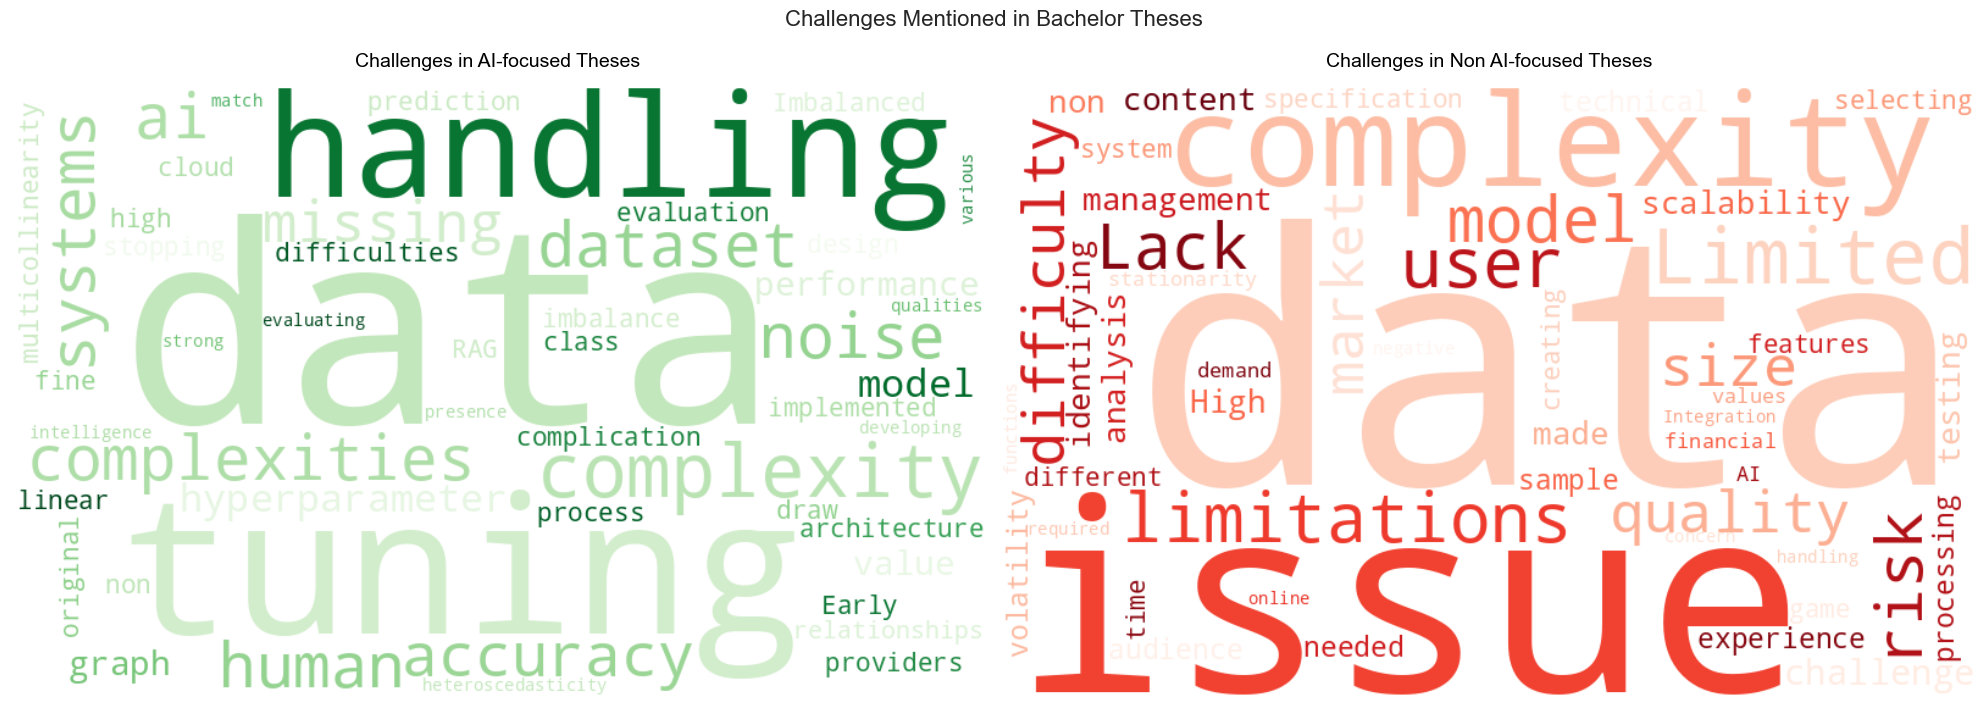

In [187]:
def get_challenges_text(df):
    return " ".join([
        challenge
        for challenges in df["challenges_mentioned"].dropna()
        if isinstance(challenges, list)
        for challenge in challenges
        if isinstance(challenge, str)
    ])

ai_text = get_challenges_text(theses_metadata[theses_metadata["is_ai_focused"] == True])
non_ai_text = get_challenges_text(theses_metadata[theses_metadata["is_ai_focused"] == False])

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- AI focused ---
wordcloud_ai = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="Greens",
    max_words=50,
    collocations=False
).generate(ai_text)

axes[0].imshow(wordcloud_ai, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Challenges in AI-focused Theses", fontsize=14, pad=15)

# --- Non AI focused ---
wordcloud_non_ai = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="Reds",
    max_words=50,
    collocations=False
).generate(non_ai_text)

axes[1].imshow(wordcloud_non_ai, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Challenges in Non AI-focused Theses", fontsize=14, pad=15)

plt.suptitle("Challenges Mentioned in Bachelor Theses", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Conclusion

The analysis of student motivations, challenges, and sentiment provides an interesting 
window into the subjective experience of writing a bachelor thesis across different research 
areas.

### Motivations

The word clouds reveal a clear difference in motivation between AI and non-AI focused students. 
AI-focused students are primarily motivated by technical curiosity, words such as **machine**, 
**learning**, **classification**, **model**, and **predicting** dominate, suggesting students 
are drawn to specific AI methods and their performance. Non-AI students show a broader range 
of motivations centered around **improving**, **analyzing**, and **using** tools to solve 
business or societal problems, with terms like **market**, **development**, and **design** 
featuring prominently.

### Challenges

AI-focused theses show a distinct set of technical challenges, with **data handling**, 
**tuning**, **missing data**, **noise**, and **hyperparameter** tuning being the most 
prominent. This reflects the practical difficulties of working with real-world datasets and 
training machine learning models. Non-AI theses face broader challenges around **complexity**, 
**limitations**, **issues**, and **risk**, suggesting more conceptual and organizational 
difficulties rather than purely technical ones. Interestingly, **data** appears prominently 
in both groups, confirming that data quality and availability is a universal challenge 
regardless of whether AI is involved.

### Sentiment and Satisfaction

Both sentiment charts tell consistent story, the overwhelming majority of 
theses across all years are classified as **positive** in sentiment, with **satisfied** 
dominating the student satisfaction scores. Negative sentiment is nearly absent in both 
AI and non-AI theses across all years, and neutral sentiment accounts for only a small 
proportion.

This pattern is consistent across years and does not appear to change as AI adoption 
increases from 2024 onwards, suggesting that the growing complexity and technical demands 
of AI-focused work have not negatively impacted how students feel about their research.

It should be noted that sentiment is extracted from the introduction and conclusion sections, 
which students tend to write in a formal and optimistic tone. The consistently positive 
results may therefore partially reflect academic writing conventions rather than genuine 
emotional expression, and should be interpreted with this caveat in mind.

# Executive Summary
## AI Trends in Bachelor Theses at FIS – Strategic Overview
**Prepared for the Vice-Dean of the Faculty of Informatics and Statistics**

---

## Overview

This analysis examines the development of artificial intelligence as a research topic in 
bachelor theses submitted at the Faculty of Informatics and Statistics between 2020 and 2026. 
Using a combination of automated text classification, keyword extraction, and large language 
model analysis applied to thesis metadata and full texts, the study addresses four strategic 
questions: whether AI research is growing, in which areas it is being applied, which techniques 
are being used, and which departments and programmes are driving this development.

---

## Key Findings

### 1. AI research is growing, but is concentrated in one programme

The number of AI-focused theses has increased sharply from near zero before 2024 to 
approximately 29–36% of all theses submitted annually from 2024 onwards. However, this growth 
is heavily concentrated in the **Data Analytics** programme, which accounts for 63.9% of all 
AI-focused theses. This programme only produced its first graduating cohort in 2024, having 
launched in 2020. **Aplikovaná Informatika** contributes a further 30.6%, leaving other 
programmes with minimal AI representation.

It is important to note that this analysis covers only English-language theses. A significant 
number of Czech-language theses were excluded from the data gathering phase, meaning the true 
proportion of AI-focused research across all programmes is likely higher than reported here.

### 2. AI is primarily applied in data science, analytics, and education

Among AI-focused theses, the dominant application areas are **data science and analytics** 
(11 theses) and **education and research** (7 theses). Business, finance, and marketing 
applications are emerging but remain modest. Notably, areas such as software development, 
logistics, and energy, which are seeing significant AI adoption in industry, are not yet 
represented as primary AI research topics among students, suggesting untapped potential for 
curriculum development in applied domains.

### 3. Techniques are evolving rapidly toward deep learning and LLMs

In 2024, students primarily worked with classical machine learning methods such as **XGBoost**, 
**logistic regression**, and early **large language model** applications. By 2025, the 
landscape had broadened significantly to include **deep learning**, **TensorFlow**, **neural 
networks**, and more advanced LLM techniques. **Python** remains the consistent foundation 
across all years. This evolution suggests that students should possess a strong understanding 
of Python fundamentals before working with more complex libraries such as TensorFlow.

### 4. AI research is led by one department

AI-focused research is predominantly supervised by **Katedra informačního a znalostního 
inženýrství**, which accounts for 17 of the 36 AI-focused theses, nearly half of the total. 
This concentration is largely explained by the department's role in supervising the Data 
Analytics programme, whose first cohort graduated in 2024. Other departments including 
Katedra informačních technologií and Katedra ekonometrie are beginning to supervise AI-focused 
work but at a much smaller scale. This uneven distribution presents an opportunity for the 
faculty to invest in building AI supervision expertise more broadly, ensuring that students 
across all programmes have access to qualified guidance as interest in AI continues to grow.

### 5. Students are engaged, motivated, and satisfied

Sentiment analysis of thesis introductions and conclusions reveals that students writing 
AI-focused theses are primarily motivated by technical curiosity, the desire to apply and 
evaluate specific machine learning methods. Satisfaction levels are high across both AI and 
non-AI theses, with negative sentiment nearly absent. The primary challenges reported by 
AI students relate to data quality, handling missing data, and hyperparameter tuning, 
practical difficulties inherent to applied machine learning work.

---

## Recommendations

**1. Extend data collection to Czech-language theses.**
The current analysis covers only English-language theses, systematically excluding a large 
portion of student work. A complete picture of AI adoption across the faculty requires 
extending classification to Czech abstracts and full texts.

**2. Support AI supervision capacity beyond the current two departments.**
With AI research growing rapidly, the faculty should consider developing AI supervision 
expertise across a broader range of departments to avoid bottlenecks and to encourage 
interdisciplinary AI applications in areas such as finance, logistics, and public sector 
research.

**3. Introduce applied AI tracks in non-technical programmes.**
The near absence of AI-focused theses from programmes outside Data Analytics and Aplikovaná 
Informatika represents a missed opportunity. Introducing structured guidance on AI 
applications in economics, marketing, and management programmes could significantly broaden 
the faculty's research portfolio.

**4. Monitor the LLM and generative AI trend closely.**
The rapid shift toward large language models and generative AI techniques in 2024–2025 
suggests students are working at these fields specificaly. The faculty should ensure that 
supervisors have the expertise to guide this work effectively and that ethical considerations 
around AI use in research are clearly communicated to students.

**5. Leverage the Data Analytics programme as a model.**
The Data Analytics programme has demonstrably driven AI research growth at the faculty. Its 
structure, curriculum, and English-language delivery appear to be key factors. These elements 
could serve as a model for developing or updating other programmes that aim to increase 
research output in emerging technology areas.

**6. Improve student access to data for research purposes.**
A recurring challenge identified across AI-focused and not AI-focused theses is the difficulty of obtaining 
sufficient, high-quality data for analysis and model training. Many students are limited to 
publicly available datasets, which are often too small, too generic, or insufficiently 
representative of the specific problem being studied. The faculty should explore establishing 
partnerships with industry organisations and public institutions to provide students with 
access to real-world datasets under appropriate data agreements. A faculty-level data 
catalogue listing available datasets, their sources, and terms of use would significantly 
lower the barrier for students undertaking data-intensive research and improve the overall 
quality and practical relevance of bachelor theses.

---

## Limitations

This analysis is based on a corpus of 162 English-language bachelor theses submitted between 
2020 and 2026. Classification was performed using automated methods including zero-shot 
classification, large language model prompting, and keyword extraction, all of which carry 
inherent uncertainty. Results should be treated as indicative trends rather than precise 
counts, even more so in the 2026 where most of theses did not have available full text at the time of analysis,
every step in analysis is saved as different metadata with name coresponding with added information.
The last metadata with every information is theses_with_sentiment.csv